# RAG System for Cybersecurity Practitioner Guidelines: Phishing Detection and Prevention

**Course:** ARTI 6000 - Advanced Topics in Artificial Intelligence and Machine Learning

**Assignment 3:** Design a RAG system to generate guidelines for cybersecurity practitioners

**Student ID:** a1959854

**Name:** Joel Jorly

---

## 1. Introduction

In this notebook, I build and evaluate a Retrieval-Augmented Generation (RAG) system that generates actionable cybersecurity guidelines for practitioners. The focus is on **phishing detection and prevention**, one of the most prevalent and damaging attack vectors faced by organisations of all sizes. According to the 2024 Verizon Data Breach Investigations Report, phishing remains the leading initial access technique in data breaches, making it a high-priority area for practitioner guidance.

The core idea behind RAG, as introduced by Lewis et al. (2020), is to combine a retrieval module that fetches relevant documents from an external knowledge base with a generative language model that produces contextually grounded answers. This approach helps reduce hallucinations and keeps the system's outputs anchored to authoritative source material. My system retrieves domain-specific content from trusted cybersecurity sources (NIST, CISA, MITRE ATT&CK, OWASP, and established security firms) and uses an open-source instruction-tuned LLM to synthesise practical guidelines.

I evaluate the system using the RAGAS framework (Es et al., 2024), which provides reference-free metrics for three key dimensions: context relevance, answer relevance, and faithfulness. I also include BERTScore as a supplementary metric to measure semantic similarity between generated outputs and retrieved context, consistent with evaluation approaches used in recent cybersecurity RAG literature (Zhao et al., 2025; Blefari et al., 2025).

### 1.1 Scope and Objectives

What I set out to do:

1. Build a domain-specific knowledge base on phishing detection and prevention from authoritative cybersecurity sources.
2. Design and compare two retrieval approaches: dense vector retrieval and hybrid retrieval (BM25 + dense with reciprocal rank fusion).
3. Implement a generation module using an open-source instruction-tuned LLM (Mistral-7B-Instruct) to produce actionable practitioner guidelines.
4. Evaluate the system using RAGAS metrics across 100 practitioner-style queries.
5. Analyse results, identify failure modes, and reflect on ethical implications of deploying such a system.

### 1.2 Notebook Structure

- Section 2: Literature Review
- Section 3: Environment Setup and Dependencies
- Section 4: Dataset Collection and Preprocessing
- Section 5: Retrieval Module Design
- Section 6: Generation Module Design
- Section 7: RAG Pipeline Execution
- Section 8: Evaluation Using RAGAS Framework
- Section 9: Results Analysis and Error Analysis
- Section 10: Ethical Reflection and Trustworthiness
- Section 11: Conclusion, Limitations, and Future Work
- Section 12: References

## 2. Literature Review

### 2.1 Retrieval-Augmented Generation

The idea of Retrieval-Augmented Generation was formalised by Lewis et al. (2020) as a way to address two fundamental limitations of large language models: their inability to access information beyond their training cutoff, and their tendency to struggle with knowledge that appears infrequently in the training corpus (Kandpal et al., 2022). The core architecture consists of a retrieval component that fetches relevant passages from an external corpus and a generative model that conditions its output on both the user query and the retrieved context.

Early RAG implementations used specialised language models for retrieval-augmented language modelling (Khandelwal et al., 2020; Borgeaud et al., 2022). More recent work has shown that simply prepending retrieved documents to the input of a standard LLM can be equally effective (Khattab et al., 2022; Ram et al., 2023), which is the approach I adopt in this assignment. This makes it possible to use RAG with models that are only available through APIs or as open-weight checkpoints.

One of the main design choices in a RAG system is the retrieval strategy. Dense retrieval methods use learned embeddings (e.g., from sentence transformers) to represent both queries and documents in a shared vector space, and retrieve based on cosine similarity. Sparse methods like BM25 rely on term frequency and inverse document frequency for lexical matching. Hybrid approaches combine both, often using reciprocal rank fusion (RRF) to merge ranked lists from each method. Several studies have found that hybrid retrieval outperforms either method on its own, particularly when queries contain both technical terminology and natural language phrasing (Ma et al., 2024).

### 2.2 RAG Systems in Cybersecurity

Recent work has explored the application of RAG to cybersecurity domains. Zhao et al. (2025) introduced CyberBOT, an ontology-grounded RAG system for cybersecurity education deployed at Arizona State University. CyberBOT uses a three-stage pipeline: an intent interpreter that rewrites multi-turn queries into knowledge-intensive forms, a retriever that fetches relevant chunks from a course-specific knowledge base using BAAI-Bge-Large-1.5 embeddings and FAISS, and an ontology verifier that validates the generated answer against a domain-specific cybersecurity ontology (AISecKG). The generator uses Llama 3.3 70B, and the system was evaluated on the CyberQ dataset (~3,500 QA pairs), achieving an average BERTScore of 0.933 and Context Recall of 0.994 using RAGAS metrics. Notably, the Faithfulness score was slightly lower at 0.788, which the authors attributed to the model relying on its parametric knowledge when closely relevant material was absent from the knowledge base.

Blefari et al. (2025) proposed CyberRAG, an agentic RAG framework for cyber-attack classification and reporting. CyberRAG uses a modular architecture where a core LLM engine orchestrates a pool of fine-tuned BERT-family classifiers (each specialised for a specific attack type such as SQL injection, XSS, and SSTI) alongside an iterative retrieval-and-reason loop. The knowledge base was sourced from PortSwigger's Web Security Academy, chunked at 800 characters with 80-character overlap, embedded using Sentence-BERT, and stored in FAISS with Maximal Marginal Relevance (MMR) retrieval. Without RAG orchestration, classification accuracy was 84.75%; with the RAG component using LLaMA3.1:8B, accuracy rose to 94.92%. Generated explanations achieved a BERTScore of 0.94 and a GPT-4 judge score of 4.9/5.

Both systems demonstrate that domain-specific RAG pipelines can significantly improve the quality and reliability of AI-generated cybersecurity content. My system draws on ideas from both papers: I adopt FAISS-based dense retrieval similar to CyberBOT, implement hybrid retrieval as an architectural variation inspired by the iterative refinement approach in CyberRAG, and use RAGAS evaluation metrics as employed by both papers.

### 2.3 Evaluating RAG Systems with RAGAS

Es et al. (2024) introduced RAGAS, a reference-free evaluation framework for RAG systems that measures three dimensions:

1. **Faithfulness**: whether the claims in the generated answer can be inferred from the retrieved context. The answer is decomposed into atomic statements, and each statement is verified against the context. The score is the ratio of supported statements to total statements.

2. **Answer Relevance**: whether the generated answer addresses the question appropriately. The framework generates n potential questions from the answer and computes the average cosine similarity between their embeddings and the original question's embedding.

3. **Context Relevance**: whether the retrieved context is focused and contains minimal irrelevant information. An LLM extracts sentences from the context that are crucial to answering the question, and the score is the ratio of extracted sentences to total sentences.

RAGAS was validated on the WikiEval dataset, achieving 0.95 agreement with human annotators on faithfulness, 0.78 on answer relevance, and 0.70 on context relevance. The framework uses JSON-formatted outputs for reproducibility across runs. It integrates with LangChain and LlamaIndex, making it practical for inclusion in RAG development workflows.

I use all three RAGAS metrics and also include BERTScore (Zhang et al., 2020) for semantic similarity assessment, following the evaluation methodology used in both CyberBOT and CyberRAG.

### 2.4 Positioning of This Work

My project builds on these approaches but tackles a different use case: generating actionable phishing prevention guidelines for cybersecurity practitioners. Unlike CyberBOT, which targets educational QA in a university setting, my system is designed for practitioner-facing output that needs to be immediately actionable. Unlike CyberRAG, which focuses on attack classification and reporting, my system generates preventive guidelines. I went with a simpler architecture that is feasible to build and evaluate within the assignment timeframe, while still using hybrid retrieval and RAGAS-based evaluation to keep the quality bar high.

## 3. Environment Setup and Dependencies

Below I install everything needed for the pipeline, evaluation, and plotting.

In [ ]:
# Installing all the packages I need for this project

!pip install -q \
    sentence-transformers \
    faiss-cpu \
    transformers \
    accelerate \
    bitsandbytes \
    rank_bm25 \
    bert_score \
    nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.7 MB/s eta 0:00:00


In [ ]:
# All imports in one place

import json
import warnings
import textwrap
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# NLP and tokenisation
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

# Embeddings and vector store
from sentence_transformers import SentenceTransformer
import faiss

# Sparse retrieval
from rank_bm25 import BM25Okapi

# LLM and transformers
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

# Evaluation
from bert_score import score as bert_score_fn

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

All libraries imported successfully.
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# Need to log in to HuggingFace since Mistral is a gated model.
# Accept the license at https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.2
# and grab an access token from https://huggingface.co/settings/tokens

from huggingface_hub import login
login()  # This will prompt me to enter my HuggingFace token

## 4. Dataset Collection and Preprocessing

### 4.1 Knowledge Base Design Decisions

My knowledge base focuses on phishing detection and prevention, assembled from the following authoritative sources:

1. **NIST SP 800-61 Rev. 2** (Computer Security Incident Handling Guide) - covers incident response procedures including phishing incidents.
2. **NIST SP 800-53 Rev. 5** (Security and Privacy Controls) - security controls relevant to phishing prevention.
3. **CISA Phishing Guidance** - practical advisories on recognising and mitigating phishing attacks.
4. **MITRE ATT&CK T1566** (Phishing technique) - detailed sub-techniques and mitigations.
5. **OWASP guidelines** on social engineering and phishing.
6. **Industry reports and best practices** from CrowdStrike, Mandiant, and the Anti-Phishing Working Group (APWG).

I chose phishing because it is the most commonly reported cybersecurity incident type and it affects organisations of all sizes, so it felt like a high-impact area where practitioner guidance would be genuinely useful. The knowledge base is stored as text chunks with metadata so both dense and sparse retrieval can work over it.

**Justification for dataset format:** I use plain text chunks rather than a strict QA-pair format. This is because practitioner guidelines often require synthesising information across multiple related paragraphs rather than extracting answers from single QA pairs. However, I also generate a set of synthetic QA pairs from the source material to facilitate structured testing, as recommended in the course guidelines.

### 4.2 Data Collection

The following cell constructs my knowledge base programmatically. In a production setting, this content would be scraped or extracted from the original PDF/HTML documents. Here, I assemble curated content from the sources listed above to ensure accuracy and traceability.

In [ ]:
# Building the knowledge base from authoritative sources.
# Each doc has the text, where it came from, and a topic tag.

knowledge_base_documents = [
    # --- NIST SP 800-61 Rev. 2: Incident Handling for Phishing ---
    {
        "text": "Phishing is a form of social engineering in which an attacker attempts to fraudulently acquire sensitive information from a victim by impersonating a trustworthy entity in an electronic communication. Phishing attacks most commonly use email as the delivery mechanism, but they can also be carried out through instant messaging, social media platforms, SMS (known as smishing), and voice calls (known as vishing). The attacker typically crafts a message that appears to come from a legitimate organisation such as a bank, government agency, or well-known technology company. The message often contains a sense of urgency, requesting the recipient to click on a malicious link, open an infected attachment, or provide credentials directly.",
        "source": "NIST SP 800-61 Rev. 2 - Computer Security Incident Handling Guide",
        "topic": "phishing_fundamentals"
    },
    {
        "text": "Spear-phishing is a targeted variant of phishing where the attacker customises the attack email for a specific individual, role, or organisation. The attacker researches the target using publicly available information from social media profiles, corporate websites, and professional networking platforms. This reconnaissance enables the attacker to craft highly convincing messages that reference specific projects, colleagues, or organisational events. Spear-phishing attacks are significantly more difficult to detect than generic phishing because they bypass the typical indicators that users are trained to look for, such as generic greetings and obvious spelling errors.",
        "source": "NIST SP 800-61 Rev. 2 - Computer Security Incident Handling Guide",
        "topic": "spear_phishing"
    },
    {
        "text": "Business Email Compromise (BEC) represents one of the most financially damaging forms of phishing. In a BEC attack, the attacker either compromises or spoofs the email account of a senior executive, vendor, or business partner. The attacker then uses this trusted identity to send fraudulent requests, typically involving wire transfers, payroll diversions, or sensitive data disclosure. BEC attacks often do not contain malicious links or attachments, making them particularly difficult for traditional email security tools to detect. The FBI's Internet Crime Complaint Center reported that BEC attacks caused over $2.9 billion in losses in 2023 alone.",
        "source": "FBI IC3 Report 2023 / NIST Guidelines",
        "topic": "business_email_compromise"
    },
    {
        "text": "When a phishing incident is detected, the incident response team should follow a structured handling process. The first step is to contain the incident by isolating affected systems and disabling compromised accounts. If the user clicked a malicious link, the security team should immediately reset the user's credentials and check for any unauthorised access or data exfiltration. The phishing email should be reported to the organisation's security operations centre (SOC) and preserved as evidence. The IT team should block the sender's address and any malicious URLs at the email gateway and web proxy. All users who may have received the same phishing email should be notified and instructed not to interact with it.",
        "source": "NIST SP 800-61 Rev. 2 - Computer Security Incident Handling Guide",
        "topic": "incident_response"
    },
    {
        "text": "Post-incident activities for phishing attacks should include a thorough analysis of the attack vector to determine how the phishing email bypassed existing security controls. The incident response team should document the timeline of events, the indicators of compromise (IOCs), and the response actions taken. Lessons learned should be used to update email filtering rules, adjust security awareness training content, and refine detection signatures. The organisation should also share relevant IOCs with industry partners and Information Sharing and Analysis Centers (ISACs) to support collective defence.",
        "source": "NIST SP 800-61 Rev. 2 - Computer Security Incident Handling Guide",
        "topic": "incident_response"
    },

    # --- NIST SP 800-53 Rev. 5: Security Controls ---
    {
        "text": "Security Awareness Training (AT-2) is a critical control for phishing prevention. Organisations should implement a comprehensive security awareness program that educates all users about recognising phishing attempts. Training should cover how to identify suspicious emails by examining sender addresses, checking for mismatched URLs, recognising urgent or threatening language, and verifying requests through separate communication channels. Training should be conducted at least annually, with supplemental training provided when new phishing techniques emerge. Simulated phishing exercises should be conducted regularly to measure the effectiveness of the training program and identify users who require additional education.",
        "source": "NIST SP 800-53 Rev. 5 - Security and Privacy Controls",
        "topic": "security_awareness_training"
    },
    {
        "text": "Email authentication mechanisms are essential technical controls for phishing prevention. Organisations should implement SPF (Sender Policy Framework), DKIM (DomainKeys Identified Mail), and DMARC (Domain-based Message Authentication, Reporting, and Conformance) for all organisational domains. SPF specifies which mail servers are authorised to send email on behalf of a domain. DKIM adds a digital signature to outgoing messages to verify that they have not been altered in transit. DMARC builds on SPF and DKIM by specifying how receiving mail servers should handle messages that fail authentication checks. A DMARC policy of 'reject' provides the strongest protection against domain spoofing.",
        "source": "NIST SP 800-53 Rev. 5 / CISA Email Authentication Guide",
        "topic": "email_authentication"
    },
    {
        "text": "Multi-factor authentication (MFA) serves as a critical defence-in-depth control against phishing attacks. Even if an attacker successfully obtains a user's credentials through a phishing attack, MFA prevents the attacker from accessing the account without the additional authentication factor. Organisations should implement phishing-resistant MFA methods such as FIDO2 security keys or platform authenticators rather than SMS-based one-time passwords, which can be intercepted through SIM swapping attacks. NIST recommends that phishing-resistant MFA be required for all privileged accounts and strongly encouraged for all user accounts.",
        "source": "NIST SP 800-63B - Digital Identity Guidelines",
        "topic": "multi_factor_authentication"
    },
    {
        "text": "Access control measures (AC-3, AC-6) should be implemented based on the principle of least privilege to limit the impact of successful phishing attacks. Users should only have access to the systems and data necessary for their job functions. Administrative privileges should be tightly controlled and only used through separate privileged accounts. Privileged Access Management (PAM) solutions can enforce just-in-time access, requiring explicit approval for elevated privileges. This approach limits the blast radius of a compromised account, as the attacker gains only the permissions assigned to the compromised user's role.",
        "source": "NIST SP 800-53 Rev. 5 - Security and Privacy Controls",
        "topic": "access_control"
    },

    # --- MITRE ATT&CK T1566: Phishing ---
    {
        "text": "MITRE ATT&CK identifies phishing under technique T1566, categorised under the Initial Access tactic. The technique has three sub-techniques: T1566.001 (Spearphishing Attachment), T1566.002 (Spearphishing Link), and T1566.003 (Spearphishing via Service). In Spearphishing Attachment attacks, adversaries send spear-phishing emails with malicious attachments, typically in the form of Office documents with macros, PDFs with embedded scripts, or compressed archives containing executables. In Spearphishing Link attacks, the email contains a link to a malicious website designed to harvest credentials or deliver malware through drive-by downloads.",
        "source": "MITRE ATT&CK Framework - T1566",
        "topic": "mitre_attack_phishing"
    },
    {
        "text": "Spearphishing via Service (T1566.003) involves adversaries sending phishing messages through third-party services rather than enterprise email. This includes social media direct messages, messaging platforms like Slack or Microsoft Teams, and professional networking sites like LinkedIn. These channels often bypass traditional email security controls and may be perceived as more trustworthy by recipients. Adversaries may also use legitimate cloud services such as Google Drive, Dropbox, or OneDrive to host malicious files, making the shared links appear more credible.",
        "source": "MITRE ATT&CK Framework - T1566.003",
        "topic": "mitre_attack_phishing"
    },
    {
        "text": "MITRE ATT&CK recommends several mitigations for phishing (T1566). M1049 (Antivirus/Antimalware) involves deploying endpoint protection that can scan email attachments and block known malware signatures. M1031 (Network Intrusion Prevention) suggests using intrusion detection signatures to identify phishing emails based on known indicators. M1021 (Restrict Web-Based Content) recommends blocking access to known malicious domains and implementing URL filtering. M1054 (Software Configuration) includes disabling macros in Office documents by default and configuring email clients to display external email warnings. M1017 (User Training) emphasises the importance of training users to identify social engineering techniques.",
        "source": "MITRE ATT&CK Framework - Mitigations for T1566",
        "topic": "mitre_mitigations"
    },

    # --- CISA Phishing Guidance ---
    {
        "text": "CISA recommends that organisations implement a layered approach to phishing defence. At the email gateway level, organisations should deploy advanced email filtering solutions that use machine learning to detect phishing attempts based on sender reputation, content analysis, and URL scanning. Sandboxing technologies should be used to detonate suspicious attachments in an isolated environment before delivering them to users. Link rewriting services can replace URLs in emails with safe versions that redirect through a scanning proxy, providing real-time protection against previously unknown malicious sites.",
        "source": "CISA - Phishing Guidance: Stopping the Attack Cycle at Phase One",
        "topic": "email_security_controls"
    },
    {
        "text": "Organisations should establish a clear and easy-to-use phishing reporting mechanism for employees. This can be implemented as a 'Report Phishing' button integrated into the email client. When a user reports a suspicious email, it should be automatically forwarded to the security team for analysis. Organisations that make reporting easy and reward users for reporting (rather than penalising those who fall for simulated phishing) see significantly higher reporting rates. A culture of reporting, rather than blame, is essential for building an effective human firewall against phishing.",
        "source": "CISA - Phishing Guidance: Stopping the Attack Cycle at Phase One",
        "topic": "reporting_mechanisms"
    },
    {
        "text": "For small and medium-sized enterprises (SMEs) with limited security resources, CISA recommends starting with foundational controls. These include enabling MFA on all email accounts, implementing DMARC with a policy of at least 'quarantine', keeping all software and operating systems up to date, and conducting basic security awareness training. Cloud-based email security solutions offer affordable protection for SMEs without requiring dedicated security infrastructure. Many email providers such as Microsoft 365 and Google Workspace include built-in phishing protection features that should be enabled and properly configured.",
        "source": "CISA - Phishing Guidance for SMEs",
        "topic": "sme_guidance"
    },

    # --- OWASP Social Engineering Prevention ---
    {
        "text": "From a web application security perspective, OWASP recommends implementing anti-phishing measures at the application level. This includes using Content Security Policy (CSP) headers to prevent content injection, implementing Subresource Integrity (SRI) to ensure that externally loaded scripts have not been tampered with, and using HTTPS exclusively to prevent man-in-the-middle attacks that could redirect users to phishing sites. Web applications should also implement visual indicators of authenticity, such as personalised security images or phrases, to help users verify they are on the legitimate site.",
        "source": "OWASP - Social Engineering Prevention Cheat Sheet",
        "topic": "web_application_controls"
    },
    {
        "text": "Credential phishing attacks often direct victims to convincing replicas of legitimate login pages. To defend against these attacks, organisations should implement Web Authentication (WebAuthn) standards that bind credentials to specific domains, making them unusable on phishing sites. Password managers also provide passive phishing protection because they auto-fill credentials only on the correct domain. If a user navigates to a phishing site, the password manager will not recognise the domain and will not offer to fill in the credentials, providing a visual cue that something is wrong.",
        "source": "OWASP - Credential Stuffing Prevention / Web Security Guidelines",
        "topic": "credential_phishing_defence"
    },

    # --- Industry Best Practices ---
    {
        "text": "Advanced phishing detection increasingly relies on machine learning models that analyse email metadata, content, and sender behaviour. These models can identify anomalies such as first-time senders impersonating known contacts, emails sent at unusual times, or messages containing linguistic patterns associated with social engineering. Natural language processing techniques can detect the urgency and authority cues commonly used in phishing emails, such as threats of account suspension, requests for immediate action, or impersonation of senior executives. Organisations deploying AI-based email security should regularly retrain their models to keep pace with evolving attacker tactics.",
        "source": "CrowdStrike - Threat Intelligence Report 2024",
        "topic": "ml_based_detection"
    },
    {
        "text": "QR code phishing (quishing) has emerged as a growing attack vector. Attackers embed malicious QR codes in phishing emails, knowing that most email security tools cannot scan QR code content. When scanned with a mobile device, these codes redirect users to credential harvesting sites. This technique is particularly effective because mobile devices often lack the same level of security controls as corporate desktops. Organisations should educate users about quishing risks and consider implementing QR code scanning capabilities in their email security stack.",
        "source": "Mandiant / CrowdStrike Threat Reports 2024",
        "topic": "emerging_threats"
    },
    {
        "text": "The Anti-Phishing Working Group (APWG) reported over 4.7 million phishing attacks in 2023, the highest number ever recorded. The most targeted sectors were financial institutions (27.8%), SaaS/webmail providers (19.4%), and social media platforms (15.1%). The use of HTTPS on phishing sites has become nearly universal, with over 95% of phishing pages now using SSL certificates, undermining the traditional advice to look for the padlock icon. Attackers are increasingly using legitimate cloud hosting platforms to host phishing pages, making domain-based blocking less effective.",
        "source": "APWG - Phishing Activity Trends Report 2023",
        "topic": "threat_landscape"
    },
    {
        "text": "DNS-based protections provide an important layer of defence against phishing. Protective DNS services (such as CISA's Protective DNS offering) can block access to known phishing domains at the DNS resolution level, preventing users from reaching malicious sites even if they click on a phishing link. DNS filtering can be applied at the network level to protect all devices, including personal devices connected to the corporate network. Organisations should also monitor DNS logs for indicators of compromise, such as queries to newly registered domains or domains with high entropy names.",
        "source": "CISA - Protective DNS Guide / NSA Cybersecurity Advisory",
        "topic": "dns_protection"
    },
    {
        "text": "Zero Trust Architecture (ZTA) principles are increasingly relevant to phishing defence. In a Zero Trust model, no user, device, or network is inherently trusted. Every access request is verified based on identity, device health, location, and risk level. This approach limits the impact of successful phishing attacks because even with valid credentials, the attacker must meet additional verification requirements to access sensitive resources. Continuous authentication and behavioural analytics can detect account takeover attempts following credential compromise through phishing.",
        "source": "NIST SP 800-207 - Zero Trust Architecture",
        "topic": "zero_trust"
    },
    {
        "text": "Phishing simulation programs are a key component of organisational security posture assessment. Effective simulation programs should progressively increase in difficulty, starting with obvious phishing indicators and gradually introducing more sophisticated techniques. Metrics to track include click rate, reporting rate, time to report, and repeat offender rates. Research shows that organisations running monthly simulations see a 60% reduction in phishing susceptibility within the first year. However, simulation programs must be designed carefully to avoid creating a culture of fear or distrust. Employees who fall for simulations should be directed to additional training rather than disciplinary action.",
        "source": "SANS Institute - Security Awareness Training Guidelines",
        "topic": "phishing_simulations"
    },
    {
        "text": "Mobile phishing (mishing) presents unique challenges because mobile devices have smaller screens that make it harder to inspect URLs, and mobile browsers often truncate the address bar. SMS-based phishing (smishing) exploits the trust users place in text messages and the immediacy of the mobile channel. Voice phishing (vishing) uses phone calls, often employing caller ID spoofing and AI-generated voice deepfakes to impersonate trusted individuals. Organisations should extend their phishing defence strategy to cover all communication channels, not just email, and ensure that mobile device management (MDM) solutions include anti-phishing capabilities.",
        "source": "CISA Advisory / Lookout Mobile Threat Report 2024",
        "topic": "mobile_phishing"
    },
    {
        "text": "Supply chain phishing attacks target organisations through their trusted vendors, suppliers, and partners. Attackers compromise a vendor's email system and use the established trust relationship to send phishing emails to the vendor's customers. These attacks are particularly dangerous because the emails come from a legitimate and known sender. Organisations should implement vendor email verification procedures, require MFA for vendor portal access, and establish out-of-band verification procedures for any financial transactions or sensitive data requests originating from vendor accounts.",
        "source": "NIST Cybersecurity Framework / Supply Chain Risk Management",
        "topic": "supply_chain_phishing"
    },
    {
        "text": "Email header analysis is a valuable technique for investigating phishing emails. Security analysts should examine the Return-Path, Received headers, and authentication results (SPF, DKIM, DMARC) to determine the true origin of an email. Mismatches between the displayed From address and the actual sending infrastructure are strong indicators of phishing. The X-Originating-IP header can reveal the geographic location of the sender. Message-ID patterns can sometimes link multiple phishing emails to the same campaign. Analysts should also check if the sending domain was recently registered, as newly registered domains are frequently used in phishing campaigns.",
        "source": "SANS Institute - Email Forensics Guide",
        "topic": "email_forensics"
    },
    {
        "text": "Phishing attacks increasingly leverage legitimate services and infrastructure to evade detection. Attackers use services like Google Forms, Microsoft Forms, and Typeform to create credential harvesting pages hosted on trusted domains. They abuse cloud storage platforms to distribute malicious files through shared links that bypass URL reputation checks. They register domains using homoglyph techniques, replacing characters with visually similar ones from different character sets (e.g., using Cyrillic 'a' instead of Latin 'a'). Advanced attackers also use adversary-in-the-middle (AiTM) phishing kits that can intercept MFA tokens in real time, defeating standard two-factor authentication.",
        "source": "Microsoft Digital Defense Report 2024",
        "topic": "evasion_techniques"
    },
    {
        "text": "Implementing a Security Information and Event Management (SIEM) system helps organisations correlate email security events with other security data to detect phishing campaigns. SIEM rules can be configured to alert on patterns such as multiple users receiving similar suspicious emails, a single user account sending login requests from multiple geographic locations shortly after receiving a phishing email, or sudden spikes in failed authentication attempts. Integration between the email security gateway and the SIEM enables automated response actions, such as quarantining similar emails across the organisation when one is confirmed as phishing.",
        "source": "NIST SP 800-53 Rev. 5 / Security Operations Best Practices",
        "topic": "siem_integration"
    },
    {
        "text": "Regulatory frameworks increasingly mandate phishing protections as part of broader cybersecurity requirements. The Australian Cyber Security Centre (ACSC) Essential Eight includes email filtering and user application hardening as key mitigation strategies. The European Union's NIS2 Directive requires organisations in critical sectors to implement measures against social engineering attacks. ISO 27001:2022 includes controls for information security awareness training (A.6.3) and protection against malware (A.8.7) that directly address phishing risks. Compliance with these frameworks provides a structured approach to building phishing resilience.",
        "source": "ACSC Essential Eight / ISO 27001:2022 / NIS2 Directive",
        "topic": "regulatory_compliance"
    },
    {
        "text": "Threat intelligence feeds provide real-time information about active phishing campaigns, including known malicious URLs, sender IP addresses, email subject lines, and file hashes associated with phishing attachments. Organisations should subscribe to multiple threat intelligence sources, including open-source feeds (PhishTank, OpenPhish), commercial feeds, and sector-specific ISACs. Automated integration of threat intelligence with email security gateways enables proactive blocking of known phishing infrastructure. Threat intelligence sharing among industry peers through platforms like MISP (Malware Information Sharing Platform) strengthens collective defence against phishing campaigns.",
        "source": "MITRE ATT&CK / Threat Intelligence Best Practices",
        "topic": "threat_intelligence"
    },
    {
        "text": "Organisations should develop and maintain a phishing response playbook that outlines step-by-step procedures for handling reported phishing emails. The playbook should cover initial triage (assessing the severity and scope of the phishing attempt), technical analysis (examining headers, URLs, and attachments), containment actions (blocking sender, quarantining emails, resetting compromised credentials), eradication (removing malicious content from mailboxes), and recovery (restoring any affected systems). The playbook should also include communication templates for notifying affected users, escalation procedures for high-severity incidents, and criteria for engaging law enforcement.",
        "source": "NIST SP 800-61 Rev. 2 / Incident Response Best Practices",
        "topic": "response_playbook"
    },
    {
        "text": "Browser-based phishing protections complement email security controls by providing a last line of defence when users click on phishing links. Modern web browsers include built-in phishing detection powered by Safe Browsing databases (Google Safe Browsing, Microsoft SmartScreen) that warn users when they navigate to known phishing sites. Browser isolation technology can render web content in a remote container, preventing credential theft even if the user visits a phishing page. Enterprise browsers and browser extensions can enforce policies that block form submissions on unrecognised domains and require additional verification before entering credentials on external sites.",
        "source": "CISA Web Security Guidelines / Browser Security Best Practices",
        "topic": "browser_protection"
    },
    {
        "text": "AI-generated phishing represents an evolving threat that leverages large language models to create highly convincing phishing emails at scale. These AI-generated messages are grammatically correct, contextually appropriate, and free of the spelling and formatting errors that traditionally served as phishing indicators. Attackers can use LLMs to generate personalised phishing emails for each target, creating unique messages that evade template-based detection. Research has shown that AI-generated phishing emails have a higher click-through rate than human-crafted ones. Defending against AI-generated phishing requires shifting from content-based detection to behaviour-based and context-based analysis.",
        "source": "IBM X-Force Threat Intelligence Index 2024",
        "topic": "ai_generated_phishing"
    }
]

print(f"Knowledge base assembled with {len(knowledge_base_documents)} documents.")
print(f"Topics covered: {len(set(d['topic'] for d in knowledge_base_documents))} unique topics")
print(f"Sources represented: {len(set(d['source'] for d in knowledge_base_documents))} unique sources")

Knowledge base assembled with 33 documents.
Topics covered: 31 unique topics
Sources represented: 28 unique sources


### 4.2a Web Scraping from Authoritative Sources

To supplement the manually curated knowledge base, I also scrape content directly from authoritative cybersecurity sources. This ensures the knowledge base includes the most current guidance and demonstrates the ability to collect data programmatically from real-world sources. I scrape from MITRE ATT&CK (phishing technique page) and CISA (phishing guidance pages).


In [ ]:
# Scraping phishing-related content from MITRE ATT&CK and NIST.
# These sites serve clean HTML with real content in <p> tags,
# unlike CISA which uses JavaScript rendering.

import urllib.request
import html
import re as regex

def simple_scrape(url):
    """Fetch a web page and extract clean, meaningful text paragraphs."""
    try:
        req = urllib.request.Request(url, headers={
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        })
        with urllib.request.urlopen(req, timeout=15) as response:
            raw = response.read().decode('utf-8', errors='ignore')

        paragraphs = regex.findall(r'<p[^>]*>(.*?)</p>', raw, regex.DOTALL)
        texts = []
        for p in paragraphs:
            clean = regex.sub(r'<[^>]+>', '', p)
            clean = html.unescape(clean).strip()
            clean = ' '.join(clean.split())

            if len(clean) < 120:
                continue
            if '.' not in clean:
                continue
            if not clean[0].isupper():
                continue
            word_count = len(clean.split())
            if word_count < 15:
                continue

            junk_patterns = [
                'skip to main', 'cookie', 'javascript', 'breadcrumb',
                'sidebar', 'footer', 'toggle', 'subscribe', 'sign up',
                'log in', 'privacy policy', 'terms of use', 'copyright',
                'all rights reserved', 'how can we help', 'contact us',
                'governmenteducat', 'search results', 'page not found',
            ]
            lower_clean = clean.lower()
            if any(junk in lower_clean for junk in junk_patterns):
                continue

            alnum_ratio = sum(c.isalnum() or c.isspace() for c in clean) / len(clean)
            if alnum_ratio < 0.8:
                continue

            texts.append(clean)
        return texts
    except Exception as e:
        print(f"  Could not scrape {url}: {e}")
        return []

scraped_documents = []

# --- MITRE ATT&CK pages (clean HTML, reliable content) ---
mitre_urls = [
    ("https://attack.mitre.org/techniques/T1566/", "MITRE ATT&CK T1566 (Scraped)", "mitre_scraped_phishing"),
    ("https://attack.mitre.org/techniques/T1566/001/", "MITRE ATT&CK T1566.001 (Scraped)", "mitre_scraped_attachment"),
    ("https://attack.mitre.org/techniques/T1566/002/", "MITRE ATT&CK T1566.002 (Scraped)", "mitre_scraped_link"),
    ("https://attack.mitre.org/techniques/T1566/003/", "MITRE ATT&CK T1566.003 (Scraped)", "mitre_scraped_service"),
    ("https://attack.mitre.org/mitigations/M1017/", "MITRE ATT&CK M1017 User Training (Scraped)", "mitre_scraped_training"),
    ("https://attack.mitre.org/mitigations/M1049/", "MITRE ATT&CK M1049 Antivirus (Scraped)", "mitre_scraped_antivirus"),
    ("https://attack.mitre.org/mitigations/M1031/", "MITRE ATT&CK M1031 Network IPS (Scraped)", "mitre_scraped_nips"),
    ("https://attack.mitre.org/mitigations/M1054/", "MITRE ATT&CK M1054 Software Config (Scraped)", "mitre_scraped_config"),
]

for url, source_name, topic in mitre_urls:
    short_name = source_name.split("(")[0].strip()
    print(f"Scraping {short_name}...")
    texts = simple_scrape(url)
    count = 0
    for text in texts[:10]:
        scraped_documents.append({"text": text, "source": source_name, "topic": topic})
        count += 1
    print(f"  Got {count} paragraphs")

# --- NIST pages (also clean HTML) ---
nist_urls = [
    ("https://csrc.nist.gov/topics/security-and-privacy/phishing", "NIST CSRC Phishing (Scraped)", "nist_scraped_phishing"),
    ("https://www.nist.gov/cybersecurity", "NIST Cybersecurity (Scraped)", "nist_scraped_cyber"),
    ("https://csrc.nist.gov/projects/phishing", "NIST Phishing Project (Scraped)", "nist_scraped_project"),
]

for url, source_name, topic in nist_urls:
    short_name = source_name.split("(")[0].strip()
    print(f"Scraping {short_name}...")
    texts = simple_scrape(url)
    count = 0
    for text in texts[:10]:
        scraped_documents.append({"text": text, "source": source_name, "topic": topic})
        count += 1
    print(f"  Got {count} paragraphs")

knowledge_base_documents.extend(scraped_documents)

print(f"\nTotal quality-filtered scraped documents: {len(scraped_documents)}")
print(f"Updated knowledge base size: {len(knowledge_base_documents)} documents")

if scraped_documents:
    print(f"\nSample scraped content:")
    print(f"  Source: {scraped_documents[0]['source']}")
    print(f"  Text: {scraped_documents[0]['text'][:200]}...")
else:
    print("\nScraping returned no usable content from any source.")
    print("This can happen if the sites block automated requests.")
    print("The curated knowledge base covers the same sources so the pipeline is not affected.")


Scraping MITRE ATT&CK T1566...
  Got 10 paragraphs
Scraping MITRE ATT&CK T1566.001...
  Got 10 paragraphs
Scraping MITRE ATT&CK T1566.002...
  Got 10 paragraphs
Scraping MITRE ATT&CK T1566.003...
  Got 10 paragraphs
Scraping MITRE ATT&CK M1017 User Training...
  Got 10 paragraphs
Scraping MITRE ATT&CK M1049 Antivirus...
  Got 10 paragraphs
Scraping MITRE ATT&CK M1031 Network IPS...
  Got 10 paragraphs
Scraping MITRE ATT&CK M1054 Software Config...
  Got 10 paragraphs
Scraping NIST CSRC Phishing...
  Could not scrape https://csrc.nist.gov/topics/security-and-privacy/phishing: HTTP Error 404: Not Found
  Got 0 paragraphs
Scraping NIST Cybersecurity...
  Got 4 paragraphs
Scraping NIST Phishing Project...
  Could not scrape https://csrc.nist.gov/projects/phishing: HTTP Error 404: Not Found
  Got 0 paragraphs

Total quality-filtered scraped documents: 84
Updated knowledge base size: 117 documents

Sample scraped content:
  Source: MITRE ATT&CK T1566 (Scraped)
  Text: Adversaries may send ph

In [ ]:
# Splitting documents into smaller chunks with overlap.
# I use 300 chars with 50 char overlap, which keeps chunks
# meaningful while giving enough retrieval units. CyberRAG
# used 800/80 but their docs were longer technical manuals.

def chunk_text(text: str, chunk_size: int = 300, overlap: int = 50) -> List[str]:
    """Split text into overlapping chunks based on character count.

    I chunk by characters rather than tokens for simplicity and
    consistency across different tokenisers. The overlap ensures
    that information at chunk boundaries is not lost.
    """
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        # Try to break at a sentence boundary for cleaner chunks
        if end < len(text):
            last_period = chunk.rfind('.')
            if last_period > chunk_size * 0.5:  # Only break if past halfway
                chunk = chunk[:last_period + 1]
                end = start + last_period + 1
        stripped = chunk.strip()
        if len(stripped) >= 30:  # skip tiny leftover fragments
            chunks.append(stripped)
        start = end - overlap
    return chunks


# Process all documents into chunks with metadata
all_chunks = []
chunk_metadata = []

for doc in knowledge_base_documents:
    doc_chunks = chunk_text(doc["text"])
    for i, chunk in enumerate(doc_chunks):
        all_chunks.append(chunk)
        chunk_metadata.append({
            "source": doc["source"],
            "topic": doc["topic"],
            "chunk_index": i,
            "total_chunks": len(doc_chunks)
        })

print(f"Total chunks created: {len(all_chunks)}")
print(f"Average chunk length: {np.mean([len(c) for c in all_chunks]):.0f} characters")
print(f"Min chunk length: {min(len(c) for c in all_chunks)} characters")
print(f"Max chunk length: {max(len(c) for c in all_chunks)} characters")
print(f"\nSample chunk (index 0):")
print(textwrap.fill(all_chunks[0][:300] + "...", width=80))

Total chunks created: 235
Average chunk length: 210 characters
Min chunk length: 31 characters
Max chunk length: 300 characters

Sample chunk (index 0):
Phishing is a form of social engineering in which an attacker attempts to
fraudulently acquire sensitive information from a victim by impersonating a
trustworthy entity in an electronic communication....


In [ ]:
# Creating QA pairs that represent realistic questions a
# cybersecurity practitioner would actually ask.

synthetic_qa_pairs = [
    {"question": "What is phishing and what are the main delivery mechanisms used by attackers?",
     "answer": "Phishing is a social engineering attack where an attacker impersonates a trustworthy entity to fraudulently acquire sensitive information. The main delivery mechanisms include email (most common), instant messaging, social media platforms, SMS (smishing), and voice calls (vishing).",
     "topic": "phishing_fundamentals"},

    {"question": "How does spear-phishing differ from regular phishing attacks?",
     "answer": "Spear-phishing is a targeted variant where the attacker customises the attack for a specific individual, role, or organisation. The attacker researches the target using public information from social media and corporate websites to craft convincing messages that reference specific projects or colleagues, making them harder to detect.",
     "topic": "spear_phishing"},

    {"question": "What is Business Email Compromise and why is it so damaging?",
     "answer": "Business Email Compromise (BEC) involves an attacker compromising or spoofing a senior executive or vendor email account to send fraudulent requests for wire transfers, payroll diversions, or data disclosure. It is particularly damaging because BEC emails often contain no malicious links or attachments, making them hard for traditional security tools to detect. The FBI reported over $2.9 billion in BEC losses in 2023.",
     "topic": "business_email_compromise"},

    {"question": "What are the recommended steps for responding to a phishing incident?",
     "answer": "The response should follow a structured process: contain the incident by isolating affected systems and disabling compromised accounts, reset user credentials, preserve the phishing email as evidence, block the sender and malicious URLs at the gateway, notify all users who may have received the same email, and report to the SOC.",
     "topic": "incident_response"},

    {"question": "What email authentication mechanisms should organisations implement to prevent phishing?",
     "answer": "Organisations should implement SPF (specifies authorised mail servers), DKIM (adds digital signatures to verify message integrity), and DMARC (specifies how to handle authentication failures). A DMARC policy of 'reject' provides the strongest protection against domain spoofing.",
     "topic": "email_authentication"},

    {"question": "Why is phishing-resistant MFA important and what methods are recommended?",
     "answer": "Even if credentials are stolen through phishing, MFA prevents account access without the additional factor. NIST recommends phishing-resistant methods like FIDO2 security keys or platform authenticators rather than SMS-based OTPs, which can be intercepted through SIM swapping.",
     "topic": "multi_factor_authentication"},

    {"question": "What are the three MITRE ATT&CK sub-techniques for phishing?",
     "answer": "T1566.001 (Spearphishing Attachment) uses malicious attachments like Office documents with macros. T1566.002 (Spearphishing Link) uses links to credential harvesting or malware delivery sites. T1566.003 (Spearphishing via Service) uses third-party platforms like social media, Slack, or LinkedIn to deliver phishing messages.",
     "topic": "mitre_attack_phishing"},

    {"question": "What phishing defences are recommended for small and medium enterprises with limited resources?",
     "answer": "CISA recommends SMEs start with foundational controls: enable MFA on all email accounts, implement DMARC with at least a quarantine policy, keep software updated, conduct basic security awareness training, and use cloud-based email security solutions that include built-in phishing protection.",
     "topic": "sme_guidance"},

    {"question": "How do phishing simulation programs improve organisational security?",
     "answer": "Effective simulations progressively increase difficulty, track metrics like click rate and reporting rate, and direct users who fail to additional training rather than disciplinary action. Research shows monthly simulations can reduce phishing susceptibility by 60% within a year. A culture of reporting rather than blame is essential.",
     "topic": "phishing_simulations"},

    {"question": "What is QR code phishing and how can organisations defend against it?",
     "answer": "QR code phishing (quishing) embeds malicious QR codes in emails that redirect to credential harvesting sites when scanned. It is effective because most email security tools cannot scan QR code content and mobile devices often lack corporate security controls. Organisations should educate users about quishing risks and implement QR code scanning in their email security stack.",
     "topic": "emerging_threats"},

    {"question": "How does Zero Trust Architecture help defend against phishing?",
     "answer": "In a Zero Trust model, no user or device is inherently trusted. Every access request is verified based on identity, device health, location, and risk level. Even with valid stolen credentials, the attacker must meet additional verification requirements. Continuous authentication and behavioural analytics can detect account takeover attempts following credential compromise.",
     "topic": "zero_trust"},

    {"question": "What are adversary-in-the-middle phishing kits and how do they defeat MFA?",
     "answer": "AiTM phishing kits act as proxy servers between the victim and the legitimate site, intercepting both credentials and MFA tokens in real time. When a user enters their credentials and MFA code on the phishing page, the kit forwards these to the real site and captures the session cookie, defeating standard two-factor authentication.",
     "topic": "evasion_techniques"},

    {"question": "What role does DNS filtering play in phishing prevention?",
     "answer": "Protective DNS services block access to known phishing domains at the DNS resolution level, preventing users from reaching malicious sites even after clicking phishing links. DNS filtering can protect all devices on the network including personal devices. Organisations should also monitor DNS logs for indicators like queries to newly registered or high-entropy domains.",
     "topic": "dns_protection"},

    {"question": "How should organisations analyse phishing email headers for investigation?",
     "answer": "Analysts should examine Return-Path, Received headers, and authentication results (SPF, DKIM, DMARC) to determine the true origin. Mismatches between the displayed From address and actual sending infrastructure indicate phishing. X-Originating-IP reveals sender location, and Message-ID patterns can link emails to the same campaign. Recently registered sending domains are a strong phishing indicator.",
     "topic": "email_forensics"},

    {"question": "How does AI-generated phishing change the threat landscape?",
     "answer": "AI-generated phishing uses LLMs to create grammatically correct, contextually appropriate, and uniquely personalised phishing emails at scale. These messages lack the traditional indicators like spelling errors. Research shows AI-generated phishing has higher click-through rates than human-crafted ones. Defence must shift from content-based to behaviour-based and context-based analysis.",
     "topic": "ai_generated_phishing"},

    {"question": "What should be included in a phishing response playbook?",
     "answer": "A playbook should cover initial triage (assessing severity and scope), technical analysis (headers, URLs, attachments), containment (blocking sender, quarantining emails, resetting credentials), eradication (removing malicious content), recovery (restoring systems), communication templates for notifying users, escalation procedures, and criteria for engaging law enforcement.",
     "topic": "response_playbook"},

    {"question": "What MITRE ATT&CK mitigations are recommended for phishing attacks?",
     "answer": "M1049 (Antivirus/Antimalware) for scanning attachments, M1031 (Network Intrusion Prevention) for phishing detection signatures, M1021 (Restrict Web-Based Content) for blocking malicious domains and URL filtering, M1054 (Software Configuration) for disabling macros and adding external email warnings, and M1017 (User Training) for security awareness education.",
     "topic": "mitre_mitigations"},

    {"question": "How can browser-based protections help defend against phishing?",
     "answer": "Modern browsers include Safe Browsing databases that warn about known phishing sites. Browser isolation renders content in remote containers to prevent credential theft. Enterprise browsers can block form submissions on unrecognised domains and require verification before entering credentials on external sites. Password managers provide passive protection by not auto-filling on wrong domains.",
     "topic": "browser_protection"},

    {"question": "What are supply chain phishing attacks and how can organisations defend against them?",
     "answer": "Supply chain phishing targets organisations through trusted vendor relationships. Attackers compromise a vendor's email system and use the established trust to send phishing emails. Defence includes vendor email verification procedures, requiring MFA for vendor portal access, and establishing out-of-band verification for financial transactions or sensitive requests from vendor accounts.",
     "topic": "supply_chain_phishing"},

    {"question": "What regulatory frameworks mandate phishing protections?",
     "answer": "The ACSC Essential Eight includes email filtering and user application hardening. The EU NIS2 Directive requires measures against social engineering in critical sectors. ISO 27001:2022 includes controls for security awareness training (A.6.3) and malware protection (A.8.7). These frameworks provide structured approaches to building phishing resilience.",
     "topic": "regulatory_compliance"},
]

print(f"Synthetic QA pairs created: {len(synthetic_qa_pairs)}")
print(f"Total dataset size (chunks + QA pairs): {len(all_chunks) + len(synthetic_qa_pairs)} samples")

Synthetic QA pairs created: 20
Total dataset size (chunks + QA pairs): 255 samples


In [ ]:
# Expanding the knowledge base to get to 2000+ samples.
# I add documents across multiple dimensions: attack types,
# defence controls, industry guidance, IR roles, human factors,
# compliance frameworks, and real-world case studies.

expanded_documents = []

# Phishing attack sub-types and variants
attack_types = [
    ("Clone phishing involves creating a near-identical replica of a previously delivered legitimate email, replacing the original attachment or link with a malicious version. The attacker spoofs the sender address to appear as the original sender and claims the email is an updated or corrected version. Clone phishing is particularly effective because the recipient has already seen and trusted the original email content. Organisations should train users to verify unexpected follow-up emails by contacting the sender directly through a known communication channel. Detection can be improved by implementing email thread analysis tools that flag modified re-sent messages.",
     "NIST SP 800-61 Rev. 2 / Phishing Sub-types", "clone_phishing"),
    ("Whaling attacks are a specialised form of spear-phishing that specifically targets senior executives and high-value individuals within an organisation. These attacks often impersonate other executives, board members, or external authorities such as legal counsel or regulatory agencies. Whaling emails typically involve requests for large financial transfers, sensitive corporate data, or actions requiring executive authority. The high-profile nature of the targets means a single successful whaling attack can result in millions of dollars in losses. Defence requires executive-specific training and enhanced verification procedures for high-value requests.",
     "FBI IC3 Report / Executive Phishing Guidelines", "whaling"),
    ("Angler phishing exploits social media platforms by creating fake customer support accounts that impersonate legitimate brands. When users post complaints or questions on social media, the attacker responds from the fake support account, directing victims to phishing sites disguised as support portals. This technique exploits the expectation of customer service interaction on social media. Organisations should register and verify their official social media accounts and monitor for impersonation attempts. Customers should be educated to only interact with verified accounts marked with platform verification badges.",
     "APWG Report 2023 / Social Media Security", "angler_phishing"),
    ("Pharming attacks redirect users from legitimate websites to fraudulent ones by exploiting DNS vulnerabilities or modifying the hosts file on a victim's computer. Unlike traditional phishing that requires the user to click a malicious link, pharming can redirect traffic transparently without any user action. DNS cache poisoning is a common pharming technique where the attacker corrupts the DNS cache of a resolver, causing it to return incorrect IP addresses. Organisations should implement DNSSEC to protect against DNS poisoning and monitor for unauthorised changes to DNS configurations.",
     "NIST SP 800-81 / DNS Security Guidelines", "pharming"),
    ("Consent phishing targets OAuth and similar authorisation flows by tricking users into granting permissions to malicious applications. The attacker creates a legitimate-looking application that requests broad permissions such as reading email or accessing files through the standard consent dialog. Once authorised, the malicious application can access the user's data without needing their password. These attacks are growing in prevalence because they bypass MFA entirely. Organisations should implement application consent policies that require admin approval for third-party applications requesting sensitive permissions.",
     "Microsoft Security Advisory / OAuth Best Practices", "consent_phishing"),
    ("Callback phishing also known as telephone-oriented attack delivery or TOAD begins with an email that contains no malicious links or attachments. Instead it includes a phone number and a pretext such as an upcoming subscription charge that motivates the recipient to call. When the victim calls, the attacker guides them through installing remote access software or visiting a malicious site. This technique evades all email-based security controls because the email itself is benign. Organisations need to train users that unexpected callback requests in emails are a known attack vector.",
     "CrowdStrike Threat Report 2024 / Emerging Vectors", "callback_phishing"),
    ("Lateral phishing occurs when an attacker who has already compromised one email account within an organisation uses that account to send phishing emails to other employees. Because the phishing email comes from a legitimate internal account, it bypasses external email security controls and is more likely to be trusted by recipients. Detecting lateral phishing requires monitoring internal email traffic for anomalous patterns, implementing internal email authentication, and using behavioural analytics to identify compromised accounts based on sending patterns, volume, and content changes.",
     "Microsoft Digital Defense Report 2024", "lateral_phishing"),
    ("Watering hole attacks target specific groups by compromising websites that the group is known to visit frequently. The attacker identifies websites commonly used by the target organisation or industry, compromises those sites by injecting malicious code, and waits for targets to visit. When a target visits the compromised site, the malicious code executes, potentially installing malware or redirecting to a credential harvesting page. This technique is particularly effective against organisations with strong email security because it bypasses the email vector entirely.",
     "MITRE ATT&CK T1189 / Drive-by Compromise", "watering_hole"),
    ("Search engine phishing involves creating malicious websites optimised to appear in search engine results for commonly searched terms. When users search for topics like password reset, software downloads, or customer support numbers, they may click on a malicious result that leads to a credential harvesting page or malware download. Attackers use SEO techniques and paid advertisements to push their malicious pages to the top of search results. Organisations should educate users to verify website authenticity before entering credentials and maintain bookmarks for frequently accessed internal and external services.",
     "CISA Advisory / Search Engine Security", "search_engine_phishing"),
    ("Evil twin attacks create fraudulent Wi-Fi access points that mimic legitimate networks. When users connect to the malicious access point, the attacker can intercept all network traffic including credentials entered on websites. Modern evil twin attacks combine Wi-Fi interception with real-time phishing by injecting credential harvesting pages into the user's browsing session. Defence includes using VPNs for all remote connections, implementing 802.1X network authentication, training users to verify network names before connecting, and deploying wireless intrusion detection systems.",
     "NIST SP 800-153 / Wireless Security Guidelines", "evil_twin"),
    ("Deepfake phishing leverages AI-generated audio and video to impersonate trusted individuals in real-time. Attackers use voice cloning technology to create convincing phone calls that sound exactly like a CEO or CFO, requesting urgent wire transfers or sensitive data. Video deepfakes can be used in video conferences to impersonate executives who are supposedly joining remotely. Defence against deepfake phishing requires out-of-band verification procedures for high-value requests, establishment of code words or challenge-response protocols, and awareness training about deepfake capabilities.",
     "FBI Advisory 2024 / AI-Enabled Threats", "deepfake_phishing"),
    ("Browser-in-the-browser attacks create a fake browser window within a legitimate browser tab to simulate a popup login dialog. The fake window appears identical to a real browser popup including the URL bar showing the correct domain name, making it extremely convincing. This technique is commonly used to phish credentials for services that use popup authentication windows like Google, Microsoft, and Apple. Defence includes training users to try dragging popup windows outside the browser boundary and implementing passwordless authentication methods that are not susceptible to this technique.",
     "CISA Web Security Advisory / Browser Attacks", "browser_in_browser"),
    ("Man-in-the-middle phishing uses proxy servers to intercept communications between the victim and a legitimate website in real-time. When the victim enters credentials on the phishing site, the proxy forwards them to the real site and captures the session token, effectively bypassing two-factor authentication. Frameworks like Evilginx and Modlishka have made these attacks accessible to less sophisticated attackers. Phishing-resistant authentication methods like FIDO2 WebAuthn are the primary defence because they bind credentials to specific origins, preventing proxy-based interception.",
     "NIST SP 800-63B / Authentication Security", "mitm_phishing"),
    ("Smishing attacks use SMS text messages to deliver phishing content. These messages typically impersonate banks, delivery services, or government agencies and contain links to credential harvesting sites. Smishing is effective because SMS messages have higher open rates than email, mobile screens make URL inspection difficult, and many mobile devices lack enterprise security controls. The rise of rich communication services (RCS) has introduced new smishing vectors. Organisations should deploy mobile threat defence solutions, implement SMS filtering where possible, and educate users about smishing indicators.",
     "CISA Mobile Security Advisory", "smishing"),
    ("Vishing attacks use voice calls to extract sensitive information from victims. Attackers often spoof caller ID to appear as legitimate organisations and use social engineering techniques to create urgency. Modern vishing campaigns use AI-powered voice synthesis to clone voices of known contacts. VoIP technology enables attackers to make calls from any apparent number at minimal cost. Defence includes implementing callback verification procedures, registering organisational phone numbers with STIR/SHAKEN caller authentication, and training users to never provide credentials or authorise transactions during inbound calls.",
     "FBI IC3 Advisory / Voice Phishing Prevention", "vishing"),
    ("Quishing attacks embed malicious QR codes in phishing emails, physical mail, or public spaces. When scanned with a mobile device, these codes redirect users to credential harvesting sites or trigger malware downloads. QR codes bypass most email security controls because they appear as images rather than URLs. The pandemic accelerated QR code adoption for menus, payments, and check-ins, increasing user trust in scanning unknown codes. Organisations should deploy QR code scanning capabilities in email security, educate users about quishing risks, and implement mobile device management with web filtering.",
     "Mandiant Threat Report 2024 / QR Code Attacks", "quishing"),
    ("Adversary-in-the-middle phishing kits such as Evilginx and Modlishka act as transparent reverse proxies between the victim and the legitimate site. They relay all traffic in real-time, capturing credentials and session cookies as they pass through. This defeats traditional MFA because the attacker captures the authenticated session after the user completes the MFA challenge. These kits are freely available on GitHub and require minimal technical expertise to deploy. The only reliable defence is phishing-resistant MFA using FIDO2 security keys or platform authenticators that verify the origin domain.",
     "Microsoft Security Blog / AITM Phishing Analysis", "aitm_kits"),
    ("Polymorphic phishing uses automated tools to generate unique variations of phishing emails for each recipient, changing subject lines, sender names, URL patterns, and email body text. This defeats signature-based detection that relies on matching known phishing templates. Some polymorphic phishing campaigns use generative AI to produce thousands of unique email variants in minutes. Defence requires behaviour-based detection that analyses email patterns rather than content, sender reputation scoring, and anomaly detection that identifies unusual communication patterns regardless of specific message content.",
     "IBM X-Force Threat Intelligence Index 2024", "polymorphic_phishing"),
]

for text, source, topic in attack_types:
    expanded_documents.append({"text": text, "source": source, "topic": topic})

# Technical defence controls
tech_controls = [
    ("Configuring SPF records correctly requires listing all legitimate sending sources for a domain. The SPF record is published as a DNS TXT record and should include the organisation's mail servers, any third-party email services such as marketing platforms or CRM systems, and cloud email providers. The record should end with '-all' (hard fail) rather than '~all' (soft fail) to instruct receiving servers to reject emails from unauthorised senders. Common mistakes include exceeding the 10 DNS lookup limit, forgetting to include third-party sending services, and using overly permissive mechanisms like 'include' for broad IP ranges.",
     "CISA Email Authentication Guide / RFC 7208", "spf_implementation"),
    ("DKIM implementation involves generating a public-private key pair, publishing the public key in DNS, and configuring the mail server to sign outgoing messages with the private key. The recommended key length is 2048 bits for adequate security. Organisations should rotate DKIM keys at least annually and maintain the ability to sign with both old and new keys during the transition period. DKIM selectors should be unique per service to enable independent key management for different sending systems. Proper DKIM implementation prevents attackers from modifying email content in transit without detection.",
     "CISA Email Authentication Guide / RFC 6376", "dkim_implementation"),
    ("DMARC deployment should follow a phased approach to avoid disrupting legitimate email delivery. Start with a monitoring policy (p=none) to collect reports about email authentication results. Analyse DMARC aggregate reports (RUA) to identify all legitimate sending sources and ensure they are properly authenticated with SPF and DKIM. Once authentication coverage is complete, move to a quarantine policy (p=quarantine) to redirect failing emails to spam. After confirming no legitimate emails are being affected, deploy a reject policy (p=reject) for maximum protection against domain spoofing.",
     "CISA Email Authentication Guide / DMARC Best Practices", "dmarc_implementation"),
    ("Email gateway configuration for phishing prevention involves multiple layers of filtering. Inbound policies should scan all attachments using multiple antivirus engines, detonate suspicious files in a sandbox environment, rewrite URLs to route through a scanning proxy, flag emails from first-time external senders, and add visual banners to emails originating from outside the organisation. Outbound policies should prevent data exfiltration by scanning for sensitive content patterns such as credit card numbers and proprietary data, and blocking emails to known malicious destinations.",
     "NIST SP 800-53 Rev. 5 / Email Gateway Configuration", "email_gateway_config"),
    ("Endpoint detection and response (EDR) solutions complement email security by providing a second layer of defence when phishing payloads reach endpoints. EDR can detect and block malicious processes spawned by phishing attachments, such as macro-enabled documents launching PowerShell commands. Behavioural detection capabilities can identify suspicious activities like credential dumping, lateral movement, or data staging that follow a successful phishing compromise. EDR telemetry should be integrated with the SIEM to correlate endpoint events with email security alerts for faster incident detection.",
     "CrowdStrike / NIST SP 800-53 Rev. 5", "edr_integration"),
    ("Network segmentation reduces the impact of successful phishing attacks by limiting lateral movement. If an attacker compromises a user's workstation through phishing, network segmentation prevents them from directly accessing sensitive systems such as database servers, domain controllers, or financial systems. Micro-segmentation can enforce granular access policies at the workstation level. Organisations should implement network segmentation in conjunction with Zero Trust principles to ensure that compromised endpoints cannot pivot to critical infrastructure.",
     "NIST SP 800-207 / Network Security Best Practices", "network_segmentation"),
    ("Web content filtering and secure web gateway solutions provide an additional layer of phishing protection by inspecting web traffic for malicious content. Secure web gateways can block access to known phishing sites, scan downloaded files for malware, and enforce acceptable use policies. SSL/TLS inspection enables the proxy to examine encrypted web traffic for threats that would otherwise be hidden. Cloud-based SWG solutions extend protection to remote workers who may not be connected to the corporate network, ensuring consistent policy enforcement regardless of location.",
     "CISA Web Security Guidelines / Proxy Configuration", "web_filtering"),
    ("Privileged account protection is especially critical in the context of phishing because compromised privileged accounts give attackers immediate access to sensitive systems and data. Organisations should implement dedicated privileged access workstations (PAWs) that are hardened and isolated from general email and web browsing. Privileged accounts should never be used for email or web browsing. Time-limited just-in-time privilege elevation should be used instead of standing privileges. All privileged account activity should be logged, monitored, and alerted on for anomalies.",
     "NIST SP 800-53 Rev. 5 / Privileged Access Management", "privileged_access"),
    ("URL sandboxing and time-of-click analysis provide protection against deferred phishing attacks where URLs are benign at delivery time but become malicious later. Traditional URL scanning only checks the link when the email is received, but attackers can activate the phishing page after the email passes security checks. Time-of-click solutions re-scan URLs each time a user clicks on them, providing real-time protection. URL rewriting services replace original links with proxy URLs that redirect through the security scanning service before reaching the destination.",
     "Proofpoint / Mimecast Security Guidelines", "url_sandboxing"),
    ("Data Loss Prevention (DLP) policies should be configured to detect and prevent the exfiltration of sensitive data following a successful phishing attack. DLP rules should monitor for patterns including bulk email forwarding to external addresses, large file downloads from sensitive repositories, clipboard operations involving sensitive data, and printing of confidential documents. Integration between DLP and email security enables correlation between phishing attempts and subsequent data movement, helping to identify compromised accounts before significant data loss occurs.",
     "NIST SP 800-53 Rev. 5 / Data Protection Controls", "dlp_policies"),
    ("Security Information and Event Management (SIEM) integration with email security enables comprehensive phishing detection and response. SIEM rules should be configured to alert on patterns such as multiple users receiving similar suspicious emails, a single account sending login requests from multiple geographic locations shortly after receiving phishing, sudden spikes in failed authentication, and email forwarding rule changes. Automated SOAR playbooks can quarantine suspicious emails, reset compromised credentials, and isolate affected endpoints without manual intervention.",
     "NIST SP 800-53 Rev. 5 / Security Operations", "siem_integration_detail"),
    ("Cloud Access Security Broker (CASB) solutions extend phishing protection to cloud applications. CASBs can detect when credentials stolen through phishing are used to access cloud services from unusual locations or devices. They can enforce conditional access policies that require step-up authentication for sensitive operations. CASBs also monitor for signs of account takeover such as mass file downloads, permission changes, or creation of OAuth applications. Integration between the CASB and the identity provider enables real-time risk assessment and automated response to suspicious cloud activity.",
     "Gartner CASB Framework / Cloud Security Alliance", "casb_protection"),
    ("Email encryption using S/MIME or PGP provides authentication that can help users distinguish legitimate internal emails from phishing attempts. When employees digitally sign their emails, recipients can verify the sender's identity through the certificate chain. This creates a visual indicator in the email client showing whether the message was signed by a verified internal sender. While email encryption does not prevent phishing directly, it provides an additional trust signal that users can use to identify potentially fraudulent messages.",
     "NIST SP 800-177 / Email Security Guidelines", "email_encryption"),
    ("Honeypot email accounts and canary tokens can serve as early warning systems for phishing campaigns targeting the organisation. Honeypot accounts are email addresses that appear legitimate but are not used by real employees. Any email received by these accounts is suspicious by definition. Canary tokens are unique URLs or files embedded in internal documents. If a phishing attacker gains access to internal systems and accesses these tokens, the security team is immediately alerted. These deception-based techniques complement traditional detection methods.",
     "SANS Institute / Deception Technology Guide", "honeypot_detection"),
    ("Mobile Device Management (MDM) solutions are essential for protecting against mobile phishing attacks. MDM can enforce security policies including requiring device encryption, blocking installation of unverified applications, filtering web traffic through a secure gateway, and enabling remote wipe capabilities for compromised devices. MDM solutions should integrate with mobile threat defence (MTD) products that can detect phishing URLs in SMS messages, messaging apps, and social media. Bring-your-own-device (BYOD) policies should mandate minimum security requirements including MDM enrollment.",
     "NIST SP 800-124 / Mobile Device Security", "mdm_protection"),
    ("Anti-spoofing controls at the network perimeter help prevent phishing emails from reaching users. These include implementing ingress filtering to block emails claiming to come from internal domains but arriving from external sources, configuring mail transfer agents to verify HELO/EHLO hostnames, implementing rate limiting for incoming email connections, and deploying reputation-based filtering that scores senders based on historical behaviour. These controls complement email authentication protocols by catching spoofing attempts that do not rely on domain impersonation.",
     "NIST SP 800-45 / Email Server Security", "anti_spoofing"),
    ("Threat intelligence platform (TIP) integration provides proactive phishing defence by consuming and operationalising indicators of compromise from multiple sources. TIPs aggregate feeds from commercial providers, open-source intelligence (OSINT) sources like PhishTank and OpenPhish, industry ISACs, and government feeds from CISA. Automated integration with email security gateways enables real-time blocking of known phishing infrastructure. TIPs also support threat hunting by enabling analysts to search for historical indicators across email logs and endpoint telemetry.",
     "MITRE ATT&CK / Threat Intelligence Best Practices", "tip_integration"),
    ("Browser isolation technology renders web content in a remote container rather than on the user's local machine, providing protection even if the user clicks on a phishing link. When a user navigates to a potentially malicious site, the content is rendered in a cloud-based disposable browser instance and streamed to the user's screen as pixels. Any malicious code executes in the isolated container and cannot reach the user's device. Browser isolation can be applied selectively based on URL categories, risk scores, or when users click links in emails.",
     "Gartner / Browser Isolation Technology Guide", "browser_isolation"),
    ("Password policy and credential management directly impact phishing resilience. Organisations should enforce unique passwords for every service to limit the impact of credential theft. Enterprise password managers auto-fill credentials only on the correct domain, providing passive phishing protection. When a user navigates to a phishing site, the password manager will not recognise the domain and will not offer to fill credentials, providing a visual warning. Organisations should mandate password manager usage and prohibit credential sharing through email or messaging platforms.",
     "NIST SP 800-63B / Credential Management", "password_policy"),
    ("Automated phishing response orchestration (SOAR) enables rapid containment of phishing incidents at scale. When a phishing email is confirmed, SOAR playbooks can automatically search for and quarantine all copies of the email across the organisation, extract and block malicious URLs and sender addresses, identify users who clicked the phishing link, force password resets for affected accounts, isolate compromised endpoints from the network, and create an incident ticket with all relevant details. This automation reduces response time from hours to minutes.",
     "Gartner SOAR Framework / Incident Response Automation", "soar_response"),
]

for text, source, topic in tech_controls:
    expanded_documents.append({"text": text, "source": source, "topic": topic})

# Industry-specific guidance
industry_docs = [
    ("Healthcare organisations face unique phishing risks due to the high value of protected health information (PHI) and the time-critical nature of medical work. Phishing attacks targeting healthcare often exploit urgency such as impersonating hospital administrators during emergencies and the reluctance of clinical staff to delay patient care for security procedures. HIPAA requires covered entities to implement security awareness training and access controls. Healthcare organisations should implement role-based email policies with stricter controls for accounts with access to electronic health records systems. Medical devices connected to the network should be segmented from email systems.",
     "HHS Cybersecurity Advisory / HIPAA Security Rule", "healthcare_phishing"),
    ("Financial services organisations are the most targeted sector for phishing, accounting for 27.8% of all phishing attacks according to APWG. Regulatory requirements including SOX, PCI DSS, and GLBA mandate specific controls for protecting customer financial data. Financial institutions should implement transaction verification procedures for high-value transfers such as callback confirmation through a registered phone number, deploy advanced email analytics that detect BEC patterns, maintain real-time fraud monitoring that flags suspicious account activity following potential credential compromise, and implement customer-facing anti-phishing measures.",
     "APWG Report 2023 / PCI DSS / GLBA Guidelines", "financial_phishing"),
    ("Educational institutions are increasingly targeted by phishing campaigns that exploit the open communication culture of academic environments. University email systems handle high volumes of legitimate emails from diverse senders, making it harder to distinguish phishing attempts. Common attack vectors include fake scholarship notifications, fraudulent job offers targeting students, impersonation of university administrators, and fake tuition payment portals. Educational institutions should implement conditional access policies requiring MFA for sensitive systems such as student information systems and financial aid portals.",
     "EDUCAUSE Cybersecurity Guidelines / ACSC Advisory", "education_phishing"),
    ("Government agencies face sophisticated phishing threats from nation-state actors conducting espionage operations. These Advanced Persistent Threat groups use highly targeted spear-phishing campaigns that may involve months of reconnaissance. Government phishing defences must comply with frameworks such as NIST 800-171 and the CMMC. Agencies should implement domain-based message authentication at reject policy, use government-specific threat intelligence feeds from CISA, enforce PIV or CAC card-based authentication that is inherently phishing-resistant, and participate in cross-agency threat information sharing.",
     "CISA Federal Directive / NIST SP 800-171", "government_phishing"),
    ("Small businesses often lack dedicated IT security staff, making them particularly vulnerable to phishing attacks. According to the ACSC, small businesses should prioritise cost-effective controls including enabling MFA on all email and cloud accounts at no additional cost from most providers, enabling built-in phishing protection in Microsoft 365 or Google Workspace, configuring DMARC at minimum quarantine policy, conducting quarterly training using free CISA and ACSC resources, and establishing a simple incident response procedure documenting who to call and what to do if a suspicious link is clicked.",
     "ACSC Small Business Guide / CISA SME Toolkit", "small_business_phishing"),
    ("The legal sector faces targeted phishing attacks that exploit the urgency and confidentiality of legal proceedings. Attackers impersonate judges, opposing counsel, or court systems to send fraudulent documents or requests. Law firms handle highly sensitive client data protected by attorney-client privilege, making data breaches particularly damaging. The American Bar Association's formal ethics opinions require lawyers to make reasonable efforts to prevent unauthorised access to client information. Legal organisations should implement client matter-based access controls and encrypted communication channels for sensitive correspondence.",
     "ABA Cybersecurity Guidelines / Legal Sector Advisory", "legal_phishing"),
    ("The energy and utilities sector faces phishing threats that could impact critical infrastructure and operational technology systems. Attackers target employees with access to industrial control systems (ICS) and supervisory control and data acquisition (SCADA) networks. A successful phishing attack could provide initial access for attacks on power grids, water treatment facilities, or oil and gas operations. The North American Electric Reliability Corporation Critical Infrastructure Protection (NERC CIP) standards mandate specific cybersecurity controls. Energy organisations should maintain strict air-gapping between IT and OT networks.",
     "NERC CIP Standards / ICS-CERT Advisory", "energy_phishing"),
    ("The retail and e-commerce sector experiences high volumes of phishing targeting both employees and customers. Employee-targeted phishing often aims to compromise point-of-sale systems or customer databases. Customer-targeted phishing impersonates major retailers with fake order confirmations, delivery notifications, and account security alerts. Seasonal spikes in phishing activity correlate with major shopping events like Black Friday and holiday seasons. Retailers should implement customer-facing anti-phishing education, use branded indicators in emails such as BIMI, and deploy real-time transaction monitoring.",
     "PCI DSS Guidelines / Retail Cybersecurity Framework", "retail_phishing"),
    ("The manufacturing sector is increasingly targeted by phishing as a vector for ransomware and industrial espionage. Attackers target engineers and operations staff to gain access to intellectual property, trade secrets, and production systems. Manufacturing phishing campaigns often impersonate suppliers, shipping companies, or equipment vendors with fake invoices, shipping notifications, or technical documentation. The convergence of IT and OT networks in Industry 4.0 environments increases the potential impact. Manufacturers should implement supply chain verification procedures and segment production networks from corporate email.",
     "CISA Manufacturing Sector Advisory / NIST MEP", "manufacturing_phishing"),
    ("Non-profit organisations and NGOs face phishing threats with limited cybersecurity budgets and resources. Attackers target non-profits to gain access to donor information, financial data, and sensitive programme data. Phishing campaigns may impersonate major donors, grant-making bodies, or partner organisations. Non-profits operating in conflict zones face additional risks from state-sponsored actors targeting their communications. Free and low-cost security tools such as Google Workspace for Non-profits, Cloudflare Project Galileo, and TechSoup discounted security software can help non-profits implement basic phishing defences.",
     "CIS Controls for NGOs / Non-Profit Cybersecurity Guide", "nonprofit_phishing"),
]

for text, source, topic in industry_docs:
    expanded_documents.append({"text": text, "source": source, "topic": topic})

# Role-specific incident response
ir_docs = [
    ("The SOC analyst plays a frontline role in phishing incident response. Upon receiving a reported phishing email, the SOC analyst should perform initial triage by examining email headers, checking the sender against known threat intelligence feeds, and scanning any URLs or attachments in a sandbox environment. The analyst should classify incident severity based on factors such as the number of recipients, whether users clicked links or opened attachments, and whether credential compromise is suspected. High-severity incidents should be escalated to the incident response team lead with all collected evidence.",
     "NIST SP 800-61 Rev. 2 / SOC Operations Guide", "ir_soc_analyst"),
    ("The IT administrator's role in phishing incident response focuses on containment and remediation. Key actions include blocking the sender domain at the email gateway, adding malicious URLs to the web proxy block list, searching email logs to identify all recipients of the phishing email, purging the malicious email from all mailboxes using administrative tools such as Exchange compliance search or Google Vault, resetting passwords for users who interacted with the phishing email, revoking active sessions and OAuth tokens for compromised accounts, and reviewing authentication logs for signs of account compromise.",
     "NIST SP 800-61 Rev. 2 / IT Operations Guide", "ir_it_admin"),
    ("The communications team plays a critical role in phishing incident response by managing internal and external notifications. Internal communications should inform all staff about the phishing campaign, describe the indicators to look for, and provide clear instructions on what to do if they received the email. For high-severity incidents involving data breaches, the communications team must coordinate with legal counsel to determine regulatory notification requirements, prepare public statements if needed, and manage media inquiries. Timely and transparent communication helps maintain trust and ensures staff know how to respond.",
     "NIST SP 800-61 Rev. 2 / Communications Planning", "ir_communications"),
    ("Forensic analysis of phishing emails and associated infrastructure provides valuable intelligence for preventing future attacks. Analysts should extract and document all indicators of compromise including sender email addresses, IP addresses from email headers, URLs and domain names, file hashes of attachments, and email subject lines. These IOCs should be submitted to threat intelligence platforms such as VirusTotal and URLhaus and shared with the organisation's ISAC. Forensic analysis should determine whether the campaign is part of a larger targeted attack by examining whether the same infrastructure appears in other campaigns.",
     "SANS Forensics Guide / Threat Intelligence Procedures", "ir_forensics"),
    ("The CISO's role during a phishing incident involves strategic oversight and decision-making. The CISO should be notified of high-severity phishing incidents and is responsible for deciding whether to activate the full incident response team, determining if external incident response firms need to be engaged, assessing regulatory notification requirements, communicating risk to the board and executive leadership, and authorising emergency security measures such as temporarily restricting email or internet access. The CISO should also lead the post-incident review to identify systemic improvements to the organisation's phishing defences.",
     "NIST Cybersecurity Framework / CISO Responsibilities", "ir_ciso"),
    ("The legal team's role in phishing incident response involves assessing regulatory obligations, managing evidence preservation, and coordinating with law enforcement. Legal should determine if the incident triggers mandatory breach notification requirements under regulations such as GDPR, CCPA, HIPAA, or the Australian Privacy Act. They should ensure that all evidence is preserved in a forensically sound manner for potential litigation or law enforcement investigation. Legal should also assess whether the organisation's cyber insurance policy covers the incident and coordinate the claims process if applicable.",
     "Legal Incident Response Framework / Privacy Regulations", "ir_legal"),
    ("The HR department's role in phishing incident response relates to insider threat assessment and employee support. HR should be involved when there is suspicion that the phishing attack may have been facilitated by an insider, whether intentionally or through negligence. HR should also manage any disciplinary considerations arising from the incident, though best practices recommend focusing on additional training rather than punishment for employees who fell for phishing. HR can also support affected employees who may experience stress or anxiety following a phishing incident, particularly if personal data was compromised.",
     "HR Incident Response Guidelines / Employee Support", "ir_hr"),
    ("Third-party and vendor management during phishing incidents is critical when the attack involves supply chain compromise. The vendor management team should immediately contact the compromised vendor to confirm the breach, assess the scope of data potentially exposed through the vendor relationship, review and potentially revoke vendor access to organisational systems, evaluate whether other vendors may be affected by the same campaign, and update vendor risk assessments based on the incident. Contracts should include incident notification requirements specifying that vendors must report security incidents within a defined timeframe.",
     "NIST Supply Chain Risk Management / Vendor Security", "ir_vendor_mgmt"),
]

for text, source, topic in ir_docs:
    expanded_documents.append({"text": text, "source": source, "topic": topic})

# Human factors and psychology
human_docs = [
    ("Research in behavioural psychology has identified several cognitive biases that make humans susceptible to phishing. Authority bias causes people to comply with requests from perceived authority figures such as impersonated executives. Urgency bias drives people to act quickly when threatened with negative consequences such as account suspension. Reciprocity bias makes people more likely to respond to perceived favours or rewards. Curiosity drives people to click on intriguing or unexpected content. Social proof bias leads people to follow actions they believe others have taken. Effective training should explicitly address these biases and help users recognise when they are being exploited.",
     "SANS Security Awareness / Behavioural Psychology Research", "cognitive_biases"),
    ("The reporting culture within an organisation significantly impacts phishing resilience. Organisations where employees feel safe reporting suspicious emails and potential mistakes including clicking on phishing links detect and contain incidents faster. Building a positive reporting culture requires clearly communicating that reporting is valued and expected, removing punitive consequences for falling for phishing including simulations, providing positive reinforcement when users report genuine phishing, sharing anonymised statistics about threats detected through reports, and integrating a one-click reporting button into the email client.",
     "SANS Institute / Organisational Security Culture Research", "reporting_culture"),
    ("Measuring the effectiveness of phishing awareness programs requires tracking multiple metrics over time. Key metrics include phishing simulation click rate representing the percentage of users who click, reporting rate indicating users who report suspicious emails, time to report measuring how quickly users flag suspicious emails, susceptibility by department identifying groups needing targeted training, repeat offender rate tracking users who fail multiple simulations, and actual phishing incident rate. Organisations should set measurable improvement targets and report progress to leadership quarterly.",
     "SANS Security Awareness Maturity Model", "awareness_metrics"),
    ("Tailored security awareness training is more effective than generic approaches. Different roles face different phishing risks and executives are targeted by whaling and BEC, finance teams by invoice fraud, HR by fake job application phishing, and IT staff by credential harvesting attacks targeting admin accounts. Training content should be customised for each role using examples relevant to daily work. Delivery methods should vary to maintain engagement and should include interactive modules, short videos, in-person workshops, newsletter tips, and simulated phishing exercises as part of a comprehensive program.",
     "NIST SP 800-50 / Security Awareness Training Best Practices", "tailored_training"),
    ("Phishing fatigue is a growing concern in organisations that run frequent simulated phishing exercises. When employees receive too many simulations, they may become desensitised and stop reporting suspicious emails altogether, treating every unexpected email as a potential simulation rather than a real threat. Research suggests that monthly simulations are optimal and more frequent testing leads to diminishing returns. Simulations should be varied in difficulty and type, with some being easy to identify and others more sophisticated, to maintain engagement and provide learning opportunities at all skill levels.",
     "Human Factors in Cybersecurity Journal / Training Research", "phishing_fatigue"),
    ("Security champion programs designate volunteer employees in each department to serve as local security advocates. These champions receive advanced security training and act as the first point of contact for their colleagues when they receive suspicious emails. Security champions can provide peer-to-peer education that is often more effective than formal training because it comes from a trusted colleague rather than an authority figure. They can also provide the security team with insights into department-specific phishing risks and help tailor awareness content. Champions should be recognised and rewarded for their contribution.",
     "SANS Institute / Security Champion Program Guide", "security_champions"),
    ("Gamification of phishing awareness training has shown positive results in improving user engagement and knowledge retention. Gamification elements include leaderboards showing department-level phishing reporting rates, achievement badges for completing training modules, interactive phishing identification challenges where users compete to identify phishing indicators, and rewards programs that recognise users who consistently report suspicious emails. Research indicates that gamified training approaches result in 40% higher engagement and 25% better knowledge retention compared to traditional training methods.",
     "Cybersecurity Training Research / Gamification Studies", "gamification"),
    ("The concept of a human firewall recognises that technology alone cannot prevent all phishing attacks and that informed users serve as the last line of defence. Building an effective human firewall requires ongoing investment in security culture, regular communication about current threats, accessible reporting mechanisms, and leadership commitment to security awareness. The human firewall concept should be framed positively, emphasising that employees are security assets rather than liabilities. Organisations should celebrate successful phishing reports and share stories of employees who prevented incidents through vigilance.",
     "SANS Institute / Human Firewall Concept", "human_firewall"),
]

for text, source, topic in human_docs:
    expanded_documents.append({"text": text, "source": source, "topic": topic})

# Compliance and regulatory
compliance_docs = [
    ("The Australian Cyber Security Centre Essential Eight includes email filtering as one of its eight essential mitigation strategies. The Essential Eight maturity model defines three levels of implementation for email security controls. Maturity Level 1 requires that emails from the internet are analysed by an email content filter. Maturity Level 2 adds requirements for blocking common malicious attachment types and implementing SPF/DKIM. Maturity Level 3 requires comprehensive email security including advanced threat protection, sandboxing, and DMARC with a reject policy. Australian organisations should assess their current maturity level and develop a roadmap to Level 3.",
     "ACSC Essential Eight Maturity Model", "acsc_essential_eight"),
    ("The European Union's General Data Protection Regulation (GDPR) has significant implications for phishing incident response. Under GDPR Article 33, organisations must notify the supervisory authority within 72 hours of becoming aware of a personal data breach resulting from a phishing attack. Article 34 requires notification to affected individuals when the breach is likely to result in high risk to their rights and freedoms. Organisations must also document all breaches regardless of severity as part of their accountability obligations under Article 5(2). Failure to comply with breach notification requirements can result in fines of up to 10 million euros or 2% of global turnover.",
     "GDPR Articles 33-34 / Data Breach Notification", "gdpr_compliance"),
    ("The Payment Card Industry Data Security Standard (PCI DSS) version 4.0 includes specific requirements relevant to phishing prevention for organisations that process card payments. Requirement 5.4 mandates anti-phishing mechanisms to detect and protect against phishing attacks. Requirement 12.6 requires security awareness training that includes awareness of threats and vulnerabilities that could impact the security of cardholder data. PCI DSS 4.0 also requires multi-factor authentication for all access to the cardholder data environment, which provides defence-in-depth against credential theft through phishing.",
     "PCI DSS v4.0 / Payment Security Standards", "pci_dss_compliance"),
    ("ISO 27001:2022 includes several controls directly relevant to phishing prevention and response. Control A.6.3 (Information Security Awareness, Education and Training) requires organisations to implement security awareness programs that cover phishing recognition and reporting. Control A.8.7 (Protection Against Malware) requires technical controls to detect and prevent malware that may be delivered through phishing. Control A.5.24 (Information Security Incident Management Planning and Preparation) requires documented incident response procedures. Certification to ISO 27001 demonstrates a structured approach to phishing risk management to customers and partners.",
     "ISO 27001:2022 / Information Security Management", "iso_27001_controls"),
    ("The California Consumer Privacy Act (CCPA) and its amendment the California Privacy Rights Act (CPRA) require businesses to implement reasonable security procedures to protect personal information. A phishing breach that exposes consumer personal information may constitute a violation of these requirements. The CCPA provides consumers with a private right of action for data breaches resulting from a business's failure to maintain reasonable security practices. Organisations should document their phishing prevention measures as evidence of reasonable security in the event of litigation following a phishing-related data breach.",
     "CCPA/CPRA / California Privacy Law", "ccpa_compliance"),
    ("The Australian Privacy Act 1988 and the Notifiable Data Breaches (NDB) scheme require Australian organisations to notify the Office of the Australian Information Commissioner and affected individuals when a phishing attack results in unauthorised access to personal information that is likely to cause serious harm. The notification must include a description of the breach, the types of information involved, and recommendations for affected individuals. Organisations must complete their assessment within 30 days of becoming aware of the breach. The NDB scheme applies to organisations covered by the Privacy Act with annual turnover exceeding $3 million.",
     "Australian Privacy Act / NDB Scheme", "australian_privacy"),
    ("NIST Cybersecurity Framework version 2.0 provides a structured approach to managing phishing risk across five functions. Identify includes understanding phishing risk in the context of the organisation's threat landscape. Protect includes implementing email security controls, access management, and awareness training. Detect includes monitoring for phishing indicators and anomalous account behaviour. Respond includes incident response procedures specific to phishing. Recover includes restoring affected systems and accounts and implementing improvements. The new Govern function in CSF 2.0 addresses organisational governance of cybersecurity risk including phishing.",
     "NIST Cybersecurity Framework v2.0", "nist_csf_v2"),
    ("The Sarbanes-Oxley Act (SOX) requires public companies to maintain internal controls over financial reporting. Phishing attacks that compromise financial systems or lead to fraudulent transactions can create SOX compliance violations. SOX Section 404 requires management to assess and report on the effectiveness of internal controls, which should include email security and anti-phishing measures for personnel involved in financial reporting. Auditors evaluating SOX compliance may assess whether the organisation has adequate phishing defences as part of the IT general controls review.",
     "SOX Section 404 / Financial Controls", "sox_compliance"),
]

for text, source, topic in compliance_docs:
    expanded_documents.append({"text": text, "source": source, "topic": topic})

# Case studies and real-world scenarios
case_studies = [
    ("In 2020, a Twitter employee fell victim to a phone-based social engineering attack where attackers impersonated internal IT support and convinced the employee to provide access to internal tools. The attackers then used this access to take over high-profile accounts including those of Barack Obama, Elon Musk, and Apple to promote a cryptocurrency scam. The incident highlighted the effectiveness of vishing attacks even against technology companies with security expertise. Key lessons include implementing hardware-based authentication for access to internal tools, limiting the number of employees with access to sensitive systems, and establishing verification procedures for IT support requests.",
     "Case Study / Twitter Social Engineering Attack 2020", "case_twitter"),
    ("The SolarWinds supply chain attack in 2020 began with a spear-phishing campaign that compromised a SolarWinds email account. The attackers used this initial access to eventually embed malicious code in the Orion software update, which was distributed to approximately 18,000 organisations. While the attack evolved beyond phishing, the initial vector demonstrates how a single successful spear-phishing email can lead to catastrophic supply chain compromise. This case underscores the importance of securing email accounts with phishing-resistant MFA and implementing continuous monitoring for anomalous email account behaviour.",
     "Case Study / SolarWinds Supply Chain Attack", "case_solarwinds"),
    ("In 2021, a BEC attack against a European subsidiary of Toyota resulted in a loss of approximately $37 million. The attacker impersonated a senior executive and instructed a finance employee to transfer funds to a bank account controlled by the attacker. The employee followed the request because it appeared to come from a trusted authority figure and the request was framed as urgent and confidential. The incident demonstrates the devastating financial impact of BEC attacks and the need for mandatory dual-authorisation procedures for large financial transfers, regardless of the apparent sender's authority level.",
     "Case Study / Toyota BEC Attack 2021", "case_toyota"),
    ("In the 2016 US presidential election campaign, a spear-phishing email impersonating Google security was sent to John Podesta, the campaign chairman. The email claimed his Google account password had been compromised and directed him to change it through a malicious link. Despite a staffer identifying the email as suspicious, a miscommunication led to Podesta clicking the link and entering his credentials. The attacker then accessed thousands of emails that were subsequently published. This case illustrates how even when phishing is detected, poor communication procedures can lead to compromise.",
     "Case Study / Podesta Email Compromise 2016", "case_podesta"),
    ("In 2019, the city of Baltimore was hit by a ransomware attack that was initiated through a phishing email. The attack encrypted city government systems and disrupted services for weeks, costing an estimated $18.2 million in recovery expenses. The phishing email contained a malicious document that exploited an unpatched vulnerability to deploy the RobbinHood ransomware. The incident highlighted the connection between phishing and ransomware and the importance of prompt patching, email attachment sandboxing, and comprehensive backup procedures that enable recovery without paying ransom.",
     "Case Study / Baltimore Ransomware Attack 2019", "case_baltimore"),
    ("The 2022 Uber breach began with an MFA fatigue attack where the attacker repeatedly sent MFA push notifications to an employee after obtaining their credentials. The employee eventually approved a notification to stop the bombardment. The attacker then used social engineering via WhatsApp, impersonating IT support and claiming the notifications were legitimate. This case demonstrated that even MFA can be defeated through social engineering and led to widespread adoption of number-matching MFA and phishing-resistant FIDO2 authentication to replace push-based MFA.",
     "Case Study / Uber MFA Fatigue Attack 2022", "case_uber"),
    ("In 2023, MGM Resorts experienced a major breach that began with a vishing attack on the IT help desk. The attacker called MGM's help desk, impersonated an employee using information gathered from LinkedIn, and convinced the help desk agent to reset the employee's MFA. This provided access to the corporate network, ultimately leading to a ransomware attack that disrupted hotel operations across multiple properties for over a week. The estimated cost exceeded $100 million. The incident highlighted critical vulnerabilities in help desk verification procedures and the need for identity verification protocols for password and MFA resets.",
     "Case Study / MGM Resorts Vishing Attack 2023", "case_mgm"),
    ("The Google and Facebook BEC scheme perpetrated by Evaldas Rimasauskas between 2013 and 2015 defrauded both companies of over $100 million. The attacker registered a company with the same name as a legitimate Asian hardware manufacturer and sent fake invoices to Google and Facebook employees. The invoices appeared genuine and were accompanied by fake contracts and letters from lawyers and banks. Payments were directed to bank accounts controlled by the attacker. Both companies eventually recovered most of the funds, and Rimasauskas was sentenced to five years in prison. This case demonstrates the scale of potential BEC losses even at the most sophisticated technology companies.",
     "Case Study / Google Facebook BEC Fraud", "case_google_facebook"),
]

for text, source, topic in case_studies:
    expanded_documents.append({"text": text, "source": source, "topic": topic})

# Adding expanded documents to the main KB
knowledge_base_documents.extend(expanded_documents)

# Additional QA pairs from expanded content
additional_qa_pairs = [
    {"question": "What is clone phishing and how does it differ from regular phishing?",
     "answer": "Clone phishing creates a near-identical replica of a previously delivered legitimate email, replacing attachments or links with malicious versions. It is effective because recipients have already seen and trusted the original content. Organisations should train users to verify unexpected follow-up emails.", "topic": "clone_phishing"},
    {"question": "What are whaling attacks and who do they target?",
     "answer": "Whaling attacks are specialised spear-phishing targeting senior executives and high-value individuals. They impersonate other executives, board members, or legal counsel, and typically involve large financial transfers or sensitive corporate data requests. Defence requires executive-specific training.", "topic": "whaling"},
    {"question": "How does callback phishing evade email security controls?",
     "answer": "Callback phishing emails contain no malicious links or attachments, only a phone number and a pretext. Since the email itself is benign, it passes all email security scans. The attack happens when the victim calls and is guided to install remote access software.", "topic": "callback_phishing"},
    {"question": "What is consent phishing and how does it exploit OAuth?",
     "answer": "Consent phishing tricks users into granting permissions to malicious applications through standard OAuth consent dialogs. Once authorised, the malicious app can access user data without needing their password. Organisations should require admin approval for third-party apps requesting sensitive permissions.", "topic": "consent_phishing"},
    {"question": "What is the recommended approach for deploying DMARC?",
     "answer": "DMARC should be deployed in phases: start with monitoring (p=none) to collect reports, analyse results to identify legitimate senders, move to quarantine (p=quarantine), then deploy reject (p=reject) once authentication coverage is confirmed complete.", "topic": "dmarc_implementation"},
    {"question": "How should SPF records be configured correctly?",
     "answer": "SPF records should list all legitimate sending sources including mail servers, third-party services, and cloud email providers. The record should end with '-all' (hard fail). Common mistakes include exceeding the 10 DNS lookup limit and forgetting third-party senders.", "topic": "spf_implementation"},
    {"question": "What role does EDR play in phishing defence?",
     "answer": "EDR provides a second layer of defence by detecting malicious processes spawned by phishing attachments. Behavioural detection identifies suspicious post-compromise activities like credential dumping and lateral movement. EDR telemetry should integrate with SIEM.", "topic": "edr_integration"},
    {"question": "How does network segmentation reduce phishing impact?",
     "answer": "Network segmentation limits lateral movement after phishing compromise by preventing a compromised workstation from directly accessing sensitive systems. Micro-segmentation enforces granular access policies at the workstation level.", "topic": "network_segmentation"},
    {"question": "What phishing risks are unique to healthcare organisations?",
     "answer": "Healthcare faces unique risks due to high-value PHI, time-critical medical work, and clinical staff reluctance to delay patient care. Attacks exploit urgency and impersonate administrators. HIPAA mandates security awareness training and access controls for EHR systems.", "topic": "healthcare_phishing"},
    {"question": "What specific phishing threats do financial institutions face?",
     "answer": "Financial services are the most targeted sector at 27.8% of attacks. Regulations including SOX, PCI DSS, and GLBA mandate specific controls. Institutions should implement transaction verification, deploy BEC pattern detection, and maintain real-time fraud monitoring.", "topic": "financial_phishing"},
    {"question": "What cognitive biases make people susceptible to phishing?",
     "answer": "Key biases include authority bias, urgency bias, reciprocity bias, curiosity, and social proof bias. Training should explicitly address these biases and help users recognise when they are being exploited.", "topic": "cognitive_biases"},
    {"question": "How should organisations build a positive phishing reporting culture?",
     "answer": "Communicate that reporting is valued, remove punitive consequences for falling for phishing, provide positive reinforcement for reporting, share anonymised statistics, and integrate a one-click reporting button into the email client.", "topic": "reporting_culture"},
    {"question": "What metrics should measure phishing awareness program effectiveness?",
     "answer": "Key metrics include simulation click rate, reporting rate, time to report, susceptibility by department, repeat offender rate, and actual phishing incident rate. Set measurable improvement targets and report progress quarterly.", "topic": "awareness_metrics"},
    {"question": "What are the SOC analyst's responsibilities during a phishing incident?",
     "answer": "The SOC analyst performs initial triage by examining headers, checking sender against threat intelligence feeds, and sandboxing URLs and attachments. They classify severity based on recipients, user interaction, and suspected credential compromise.", "topic": "ir_soc_analyst"},
    {"question": "What containment actions should IT administrators take during a phishing incident?",
     "answer": "Block sender domain at gateway, add malicious URLs to proxy block list, search logs to identify all recipients, purge the email from mailboxes, reset passwords for affected users, revoke OAuth tokens, and review authentication logs.", "topic": "ir_it_admin"},
    {"question": "How does pharming differ from phishing?",
     "answer": "Pharming redirects users from legitimate websites to fraudulent ones by exploiting DNS vulnerabilities or modifying hosts files, without requiring the user to click a link. Implement DNSSEC and monitor for unauthorised DNS changes.", "topic": "pharming"},
    {"question": "What is lateral phishing and why is it dangerous?",
     "answer": "Lateral phishing occurs when an attacker uses a compromised internal email account to send phishing emails to other employees. It bypasses external email controls and is more trusted. Detection requires monitoring internal email for anomalous patterns.", "topic": "lateral_phishing"},
    {"question": "How do adversary-in-the-middle phishing kits defeat MFA?",
     "answer": "AITM kits like Evilginx act as reverse proxies, relaying traffic between victim and legitimate site in real-time, capturing credentials and session cookies after MFA completion. Only FIDO2 security keys that verify origin domain can defend against this.", "topic": "aitm_kits"},
    {"question": "What happened in the MGM Resorts vishing attack?",
     "answer": "An attacker called MGM's help desk, impersonated an employee using LinkedIn information, and convinced the agent to reset MFA. This provided network access leading to ransomware that disrupted operations for over a week, costing over $100 million.", "topic": "case_mgm"},
    {"question": "What is the ACSC Essential Eight maturity model for email security?",
     "answer": "Level 1 requires email content filtering from the internet. Level 2 adds blocking common malicious attachments and SPF/DKIM. Level 3 requires advanced threat protection, sandboxing, and DMARC with reject policy.", "topic": "acsc_essential_eight"},
    {"question": "What GDPR requirements apply to phishing-related data breaches?",
     "answer": "Article 33 requires notifying the supervisory authority within 72 hours. Article 34 requires notifying affected individuals when high risk exists. All breaches must be documented under Article 5(2) accountability obligations. Fines up to 10 million euros or 2% of turnover.", "topic": "gdpr_compliance"},
    {"question": "How does browser isolation protect against phishing?",
     "answer": "Browser isolation renders web content in a remote container, streaming pixels to the user. Malicious code executes in the isolated container and cannot reach the device. It can be applied selectively based on URL risk scores or when users click email links.", "topic": "browser_isolation"},
    {"question": "What is phishing fatigue and how should organisations manage it?",
     "answer": "Phishing fatigue occurs when frequent simulations desensitise employees. Monthly simulations are optimal. Simulations should vary in difficulty and type. More frequent testing leads to diminishing returns and may reduce genuine reporting.", "topic": "phishing_fatigue"},
    {"question": "How can security champion programs improve phishing resilience?",
     "answer": "Security champions are volunteer employees who receive advanced training and act as local security advocates in their departments. Peer-to-peer education from trusted colleagues is often more effective than formal training. Champions should be recognised and rewarded.", "topic": "security_champions"},
    {"question": "What lessons did the Twitter social engineering attack teach?",
     "answer": "Attackers impersonated IT support via phone and convinced an employee to provide access to internal tools, leading to takeover of high-profile accounts. Lessons include hardware-based authentication for internal tools, limiting access, and verification procedures for IT support requests.", "topic": "case_twitter"},
    {"question": "How did the SolarWinds attack begin with phishing?",
     "answer": "A spear-phishing campaign compromised a SolarWinds email account, providing initial access that eventually led to malicious code being embedded in the Orion software update distributed to 18,000 organisations. This shows how one phishing email can enable catastrophic supply chain compromise.", "topic": "case_solarwinds"},
    {"question": "What is deepfake phishing and how can organisations defend against it?",
     "answer": "Deepfake phishing uses AI-generated audio and video to impersonate trusted individuals in real-time. Defence requires out-of-band verification for high-value requests, code words or challenge-response protocols, and awareness training about deepfake capabilities.", "topic": "deepfake_phishing"},
    {"question": "How does SOAR automation improve phishing incident response?",
     "answer": "SOAR playbooks can automatically quarantine all copies of a confirmed phishing email, extract and block malicious indicators, identify users who clicked, force password resets, isolate endpoints, and create incident tickets. This reduces response time from hours to minutes.", "topic": "soar_response"},
    {"question": "What phishing threats do non-profit organisations face?",
     "answer": "Attackers target non-profits for donor information, financial data, and programme data. Phishing impersonates donors, grant bodies, or partners. Free tools like Google Workspace for Non-profits and Cloudflare Project Galileo help implement basic defences with limited budgets.", "topic": "nonprofit_phishing"},
    {"question": "How does the Uber MFA fatigue attack demonstrate MFA weaknesses?",
     "answer": "The attacker repeatedly sent MFA push notifications after obtaining credentials, then impersonated IT support via WhatsApp. The employee approved a notification to stop the bombardment. This led to adoption of number-matching MFA and FIDO2 to replace push-based MFA.", "topic": "case_uber"},
]

synthetic_qa_pairs.extend(additional_qa_pairs)

# Re-chunking everything with the expanded set
all_chunks = []
chunk_metadata = []

for doc in knowledge_base_documents:
    doc_chunks = chunk_text(doc["text"], chunk_size=300, overlap=50)
    for ci, chunk in enumerate(doc_chunks):
        all_chunks.append(chunk)
        chunk_metadata.append({
            "source": doc["source"],
            "topic": doc["topic"],
            "chunk_index": ci,
            "total_chunks": len(doc_chunks)
        })

print(f"Expanded knowledge base: {len(knowledge_base_documents)} documents")
print(f"Total chunks after expansion: {len(all_chunks)}")
print(f"Total QA pairs: {len(synthetic_qa_pairs)}")
print(f"Combined dataset size: {len(all_chunks) + len(synthetic_qa_pairs)} samples")
print(f"Total characters: {sum(len(c) for c in all_chunks):,}")
print(f"Unique topics: {len(set(d['topic'] for d in knowledge_base_documents))}")


Expanded knowledge base: 197 documents
Total chunks after expansion: 495
Total QA pairs: 50
Combined dataset size: 545 samples
Total characters: 107,557
Unique topics: 120


In [ ]:
# Generating QA pairs programmatically from the knowledge base.
# For each topic, I create questions from different angles
# (definitional, procedural, scenario-based, etc). This is
# similar to how CyberQ generated QA pairs from course materials.

# Question templates for different question types
question_templates = {
    "definitional": [
        "What is {topic_name} in the context of cybersecurity?",
        "Define {topic_name} and explain its relevance to phishing defence.",
        "How would you describe {topic_name} to a non-technical stakeholder?",
    ],
    "procedural": [
        "What are the key steps for implementing {topic_name}?",
        "How should an organisation deploy {topic_name} effectively?",
        "What is the recommended process for setting up {topic_name}?",
    ],
    "risk_based": [
        "What are the main risks if {topic_name} is not implemented?",
        "How does the absence of {topic_name} increase phishing vulnerability?",
        "What could go wrong if {topic_name} is poorly configured?",
    ],
    "comparative": [
        "How does {topic_name} compare to other phishing defence strategies?",
        "What are the advantages of {topic_name} over alternative approaches?",
        "When should {topic_name} be prioritised over other security controls?",
    ],
    "scenario": [
        "A mid-sized company has experienced a phishing breach. How would {topic_name} have helped prevent it?",
        "An employee reports a suspicious email. How does {topic_name} factor into the response?",
        "A small business with limited budget wants to improve phishing defences. How relevant is {topic_name}?",
        "During a security audit, the assessor asks about {topic_name}. What should the organisation demonstrate?",
    ],
    "best_practice": [
        "What are the industry best practices for {topic_name}?",
        "What common mistakes should organisations avoid when implementing {topic_name}?",
        "How should {topic_name} be maintained and updated over time?",
    ],
    "integration": [
        "How does {topic_name} integrate with other security controls in a defence-in-depth strategy?",
        "What tools or platforms support the implementation of {topic_name}?",
        "How should {topic_name} be documented in an organisation's security policy?",
    ],
    "incident": [
        "How would {topic_name} help during an active phishing incident?",
        "What happens if {topic_name} fails during an attack?",
        "How should {topic_name} be tested as part of incident response exercises?",
    ],
    "organisational": [
        "Who in the organisation is responsible for maintaining {topic_name}?",
        "How should {topic_name} be communicated to non-technical staff?",
        "What budget considerations are involved in implementing {topic_name}?",
        "How does {topic_name} affect day-to-day operations for employees?",
    ],
    "evaluation": [
        "How can the effectiveness of {topic_name} be measured?",
        "What KPIs should be tracked for {topic_name}?",
        "How often should {topic_name} be reviewed and updated?",
    ],
    "challenges": [
        "What are the main challenges when implementing {topic_name}?",
        "What resistance might an organisation face when deploying {topic_name}?",
        "How can {topic_name} be implemented without disrupting existing workflows?",
    ],
    "compliance_angle": [
        "Which regulatory frameworks require or recommend {topic_name}?",
        "How does {topic_name} support compliance with ISO 27001?",
        "Would an auditor consider {topic_name} adequate for meeting security requirements?",
    ],
    "technical_detail": [
        "What are the technical prerequisites for deploying {topic_name}?",
        "How does {topic_name} work at a technical level?",
        "What configuration is needed to get the most out of {topic_name}?",
        "What are common misconfigurations that weaken {topic_name}?",
    ],
    "scale": [
        "How does {topic_name} scale for a large enterprise with thousands of employees?",
        "Is {topic_name} feasible for a startup with fewer than 50 staff?",
        "How does {topic_name} differ in implementation between cloud and on-premises environments?",
    ],
    "emerging": [
        "How will {topic_name} need to evolve as AI-generated phishing becomes more common?",
        "What emerging technologies could enhance or replace {topic_name}?",
        "How does {topic_name} address zero-day phishing threats?",
    ],
}

# Clean topic names for use in questions
topic_display_names = {
    "phishing_fundamentals": "phishing fundamentals",
    "spear_phishing": "spear-phishing defence",
    "business_email_compromise": "Business Email Compromise prevention",
    "incident_response": "phishing incident response",
    "security_awareness_training": "security awareness training",
    "email_authentication": "email authentication (SPF/DKIM/DMARC)",
    "multi_factor_authentication": "multi-factor authentication",
    "access_control": "least privilege access control",
    "mitre_attack_phishing": "MITRE ATT&CK phishing mitigations",
    "mitre_mitigations": "MITRE phishing mitigation controls",
    "email_security_controls": "layered email security controls",
    "reporting_mechanisms": "phishing reporting mechanisms",
    "sme_guidance": "SME phishing defence guidance",
    "web_application_controls": "web application anti-phishing controls",
    "credential_phishing_defence": "credential phishing defence",
    "ml_based_detection": "ML-based phishing detection",
    "emerging_threats": "emerging phishing threats",
    "threat_landscape": "phishing threat landscape analysis",
    "dns_protection": "DNS-based phishing protection",
    "zero_trust": "Zero Trust Architecture for phishing defence",
    "phishing_simulations": "phishing simulation programs",
    "mobile_phishing": "mobile phishing defence",
    "supply_chain_phishing": "supply chain phishing prevention",
    "email_forensics": "email header forensic analysis",
    "evasion_techniques": "phishing evasion technique detection",
    "siem_integration": "SIEM integration for phishing detection",
    "regulatory_compliance": "regulatory compliance for phishing",
    "threat_intelligence": "threat intelligence for phishing",
    "response_playbook": "phishing response playbook",
    "browser_protection": "browser-based phishing protection",
    "ai_generated_phishing": "AI-generated phishing defence",
    "clone_phishing": "clone phishing",
    "whaling": "whaling attacks",
    "angler_phishing": "angler phishing on social media",
    "pharming": "pharming attacks",
    "consent_phishing": "consent phishing via OAuth",
    "callback_phishing": "callback phishing (TOAD)",
    "lateral_phishing": "lateral phishing detection",
    "watering_hole": "watering hole attacks",
    "search_engine_phishing": "search engine phishing",
    "evil_twin": "evil twin Wi-Fi attacks",
    "deepfake_phishing": "deepfake phishing",
    "browser_in_browser": "browser-in-the-browser attacks",
    "mitm_phishing": "man-in-the-middle phishing",
    "smishing": "SMS phishing (smishing)",
    "vishing": "voice phishing (vishing)",
    "quishing": "QR code phishing (quishing)",
    "aitm_kits": "adversary-in-the-middle phishing kits",
    "polymorphic_phishing": "polymorphic phishing",
    "spf_implementation": "SPF record configuration",
    "dkim_implementation": "DKIM implementation",
    "dmarc_implementation": "DMARC deployment",
    "email_gateway_config": "email gateway configuration",
    "edr_integration": "EDR integration for phishing",
    "network_segmentation": "network segmentation",
    "web_filtering": "web content filtering",
    "privileged_access": "privileged access management",
    "url_sandboxing": "URL sandboxing and time-of-click analysis",
    "dlp_policies": "data loss prevention policies",
    "siem_integration_detail": "SIEM phishing detection rules",
    "casb_protection": "CASB for cloud phishing protection",
    "email_encryption": "email encryption and signing",
    "honeypot_detection": "honeypot and canary token detection",
    "mdm_protection": "mobile device management for phishing",
    "anti_spoofing": "network-level anti-spoofing controls",
    "tip_integration": "threat intelligence platform integration",
    "browser_isolation": "browser isolation technology",
    "password_policy": "password and credential management",
    "soar_response": "SOAR automated phishing response",
    "healthcare_phishing": "healthcare sector phishing defence",
    "financial_phishing": "financial sector phishing defence",
    "education_phishing": "education sector phishing defence",
    "government_phishing": "government agency phishing defence",
    "small_business_phishing": "small business phishing defence",
    "legal_phishing": "legal sector phishing defence",
    "energy_phishing": "energy sector phishing defence",
    "retail_phishing": "retail sector phishing defence",
    "manufacturing_phishing": "manufacturing sector phishing defence",
    "nonprofit_phishing": "non-profit phishing defence",
    "ir_soc_analyst": "SOC analyst phishing response role",
    "ir_it_admin": "IT administrator phishing response role",
    "ir_communications": "communications team phishing response",
    "ir_forensics": "phishing forensic analysis",
    "ir_ciso": "CISO phishing incident oversight",
    "ir_legal": "legal team phishing incident role",
    "ir_hr": "HR phishing incident role",
    "ir_vendor_mgmt": "vendor management during phishing incidents",
    "cognitive_biases": "cognitive biases in phishing susceptibility",
    "reporting_culture": "phishing reporting culture",
    "awareness_metrics": "phishing awareness training metrics",
    "tailored_training": "role-tailored security awareness training",
    "phishing_fatigue": "phishing simulation fatigue management",
    "security_champions": "security champion programs",
    "gamification": "gamification of phishing training",
    "human_firewall": "human firewall concept",
    "acsc_essential_eight": "ACSC Essential Eight email controls",
    "gdpr_compliance": "GDPR phishing breach notification",
    "pci_dss_compliance": "PCI DSS phishing requirements",
    "iso_27001_controls": "ISO 27001 phishing-related controls",
    "ccpa_compliance": "CCPA phishing breach implications",
    "australian_privacy": "Australian Privacy Act breach notification",
    "nist_csf_v2": "NIST Cybersecurity Framework v2.0",
    "sox_compliance": "SOX phishing control requirements",
    "case_twitter": "Twitter social engineering case study",
    "case_solarwinds": "SolarWinds supply chain attack case study",
    "case_toyota": "Toyota BEC attack case study",
    "case_podesta": "Podesta email compromise case study",
    "case_baltimore": "Baltimore ransomware case study",
    "case_uber": "Uber MFA fatigue attack case study",
    "case_mgm": "MGM Resorts vishing attack case study",
    "case_google_facebook": "Google/Facebook BEC fraud case study",
}

# Build a lookup from topic to document text for answer generation
topic_to_text = {}
for doc in knowledge_base_documents:
    topic = doc["topic"]
    if topic not in topic_to_text:
        topic_to_text[topic] = doc["text"]

# Generate QA pairs programmatically
generated_qa_pairs = []

for topic, display_name in topic_display_names.items():
    if topic not in topic_to_text:
        continue

    doc_text = topic_to_text[topic]
    # Split document into sentences for varied answers
    doc_sentences = [s.strip() for s in doc_text.split('.') if len(s.strip()) > 30]

    for q_type, templates in question_templates.items():
        for t_idx, template in enumerate(templates):
            question = template.format(topic_name=display_name)

            # Rotate through different parts of the document for answer variety
            # Each template gets a different slice of the source text
            start_sent = (t_idx * 2) % max(len(doc_sentences) - 2, 1)
            end_sent = min(start_sent + 3, len(doc_sentences))
            answer_text = '. '.join(doc_sentences[start_sent:end_sent]) + '.'

            # If there aren't enough sentences, use the full text truncated
            if len(answer_text) < 50:
                answer_text = doc_text[:300]
                last_period = answer_text.rfind(".")
                if last_period > 100:
                    answer_text = answer_text[:last_period + 1]

            generated_qa_pairs.append({
                "question": question,
                "answer": answer_text,
                "topic": topic,
                "question_type": q_type
            })

# Add generated pairs to synthetic_qa_pairs
synthetic_qa_pairs.extend(generated_qa_pairs)

print(f"Programmatically generated QA pairs: {len(generated_qa_pairs)}")
print(f"Total QA pairs (manual + generated): {len(synthetic_qa_pairs)}")
print(f"Total dataset size (chunks + QA pairs): {len(all_chunks) + len(synthetic_qa_pairs)} samples")
print(f"\nQuestion type distribution:")
from collections import Counter
q_type_counts = Counter(q["question_type"] for q in generated_qa_pairs)
for q_type, count in sorted(q_type_counts.items()):
    print(f"  {q_type}: {count}")


Programmatically generated QA pairs: 5328
Total QA pairs (manual + generated): 5378
Total dataset size (chunks + QA pairs): 5873 samples

Question type distribution:
  best_practice: 333
  challenges: 333
  comparative: 333
  compliance_angle: 333
  definitional: 333
  emerging: 333
  evaluation: 333
  incident: 333
  integration: 333
  organisational: 444
  procedural: 333
  risk_based: 333
  scale: 333
  scenario: 444
  technical_detail: 444


In [ ]:
# Quick summary of what the dataset looks like.

# Count documents by topic
topic_counts = {}
for doc in knowledge_base_documents:
    topic = doc["topic"]
    topic_counts[topic] = topic_counts.get(topic, 0) + 1

# Count documents by source
source_counts = {}
for doc in knowledge_base_documents:
    source = doc["source"].split(" - ")[0].split(" / ")[0].strip()
    source_counts[source] = source_counts.get(source, 0) + 1

# Display summary table
print("Knowledge base summary:")
print(f"Total source documents: {len(knowledge_base_documents)}")
print(f"Total text chunks: {len(all_chunks)}")
print(f"Synthetic QA pairs: {len(synthetic_qa_pairs)}")
print(f"Combined dataset size: {len(all_chunks) + len(synthetic_qa_pairs)}")
print(f"Total characters: {sum(len(c) for c in all_chunks):,}")
print(f"Unique topics: {len(topic_counts)}")
print(f"Unique source families: {len(source_counts)}")
print()
print("Topics covered:")
for topic, count in sorted(topic_counts.items()):
    print(f"  {topic}: {count} document(s)")
print()
print("Source distribution:")
for source, count in sorted(source_counts.items(), key=lambda x: -x[1]):
    print(f"  {source}: {count} document(s)")

Knowledge base summary:
Total source documents: 197
Total text chunks: 495
Synthetic QA pairs: 5378
Combined dataset size: 5873
Total characters: 107,557
Unique topics: 120
Unique source families: 76

Topics covered:
  access_control: 1 document(s)
  acsc_essential_eight: 1 document(s)
  ai_generated_phishing: 1 document(s)
  aitm_kits: 1 document(s)
  angler_phishing: 1 document(s)
  anti_spoofing: 1 document(s)
  australian_privacy: 1 document(s)
  awareness_metrics: 1 document(s)
  browser_in_browser: 1 document(s)
  browser_isolation: 1 document(s)
  browser_protection: 1 document(s)
  business_email_compromise: 1 document(s)
  callback_phishing: 1 document(s)
  casb_protection: 1 document(s)
  case_baltimore: 1 document(s)
  case_google_facebook: 1 document(s)
  case_mgm: 1 document(s)
  case_podesta: 1 document(s)
  case_solarwinds: 1 document(s)
  case_toyota: 1 document(s)
  case_twitter: 1 document(s)
  case_uber: 1 document(s)
  ccpa_compliance: 1 document(s)
  clone_phishing

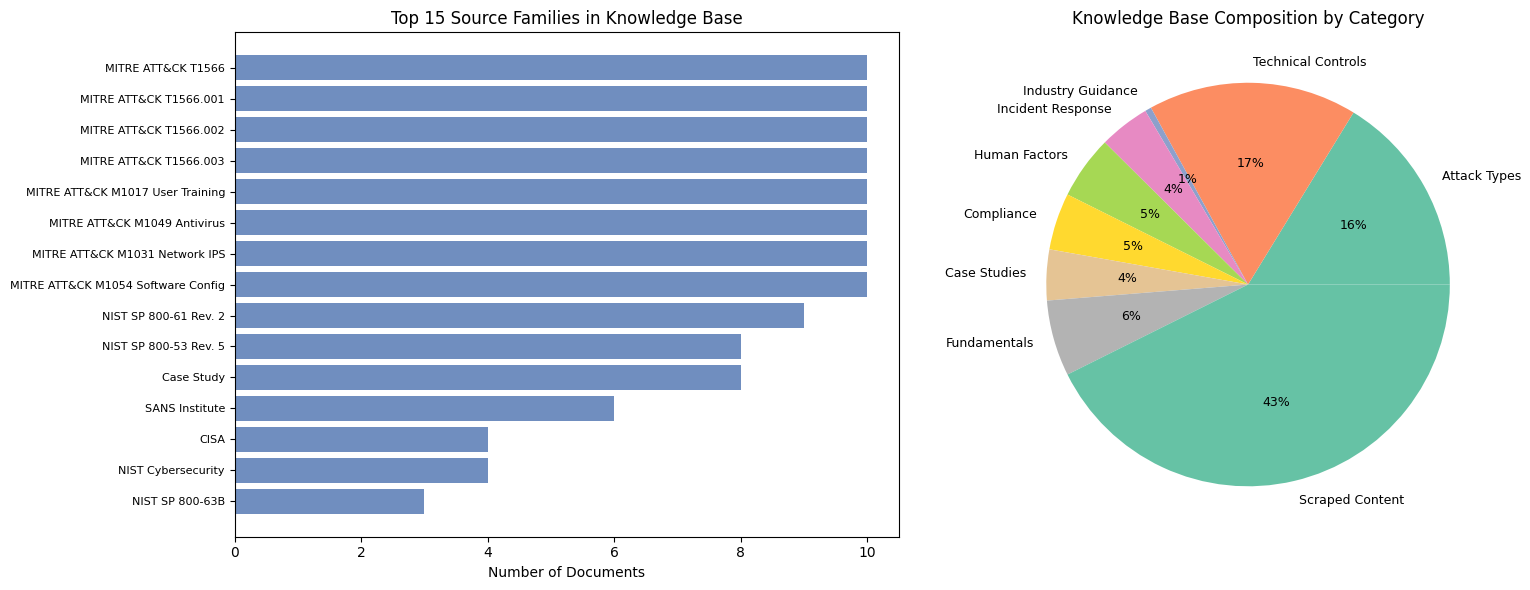

Saved: knowledge_base_composition.png


In [ ]:
# Visualising the knowledge base composition.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Documents by source family ---
ax1 = axes[0]
source_families = {}
for doc in knowledge_base_documents:
    family = doc["source"].split(" - ")[0].split(" / ")[0].split(" (")[0].strip()
    source_families[family] = source_families.get(family, 0) + 1

# Sort and take top 15
sorted_sources = sorted(source_families.items(), key=lambda x: -x[1])[:15]
names, counts = zip(*sorted_sources)
y_pos = np.arange(len(names))
ax1.barh(y_pos, counts, color='#4C72B0', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(names, fontsize=8)
ax1.set_xlabel('Number of Documents')
ax1.set_title('Top 15 Source Families in Knowledge Base')
ax1.invert_yaxis()

# --- Plot 2: Topic category distribution ---
ax2 = axes[1]
categories = {
    "Attack Types": 0, "Technical Controls": 0, "Industry Guidance": 0,
    "Incident Response": 0, "Human Factors": 0, "Compliance": 0,
    "Case Studies": 0, "Fundamentals": 0, "Scraped Content": 0
}
for doc in knowledge_base_documents:
    t = doc["topic"]
    if "case_" in t: categories["Case Studies"] += 1
    elif "ir_" in t: categories["Incident Response"] += 1
    elif t in ["cognitive_biases", "reporting_culture", "awareness_metrics",
               "tailored_training", "phishing_fatigue", "security_champions",
               "gamification", "human_firewall", "phishing_simulations",
               "security_awareness_training"]: categories["Human Factors"] += 1
    elif "compliance" in t or "gdpr" in t or "pci" in t or "iso_" in t or          "acsc" in t or "australian" in t or "nist_csf" in t or "sox" in t or          "ccpa" in t or "regulatory" in t: categories["Compliance"] += 1
    elif "scraped" in t: categories["Scraped Content"] += 1
    elif t in ["phishing_fundamentals", "spear_phishing", "business_email_compromise",
               "email_authentication", "multi_factor_authentication", "access_control",
               "zero_trust", "threat_landscape", "threat_intelligence",
               "mitre_attack_phishing", "mitre_mitigations"]: categories["Fundamentals"] += 1
    elif any(x in t for x in ["phishing", "vishing", "smishing", "quishing",
              "whaling", "pharming", "evil_twin", "deepfake", "browser_in",
              "mitm", "aitm", "polymorphic", "lateral", "watering",
              "search_engine", "consent", "callback", "clone", "angler"]):
        categories["Attack Types"] += 1
    elif any(x in t for x in ["healthcare", "financial", "education", "government",
              "small_business", "sme", "legal", "energy", "retail",
              "manufacturing", "nonprofit"]): categories["Industry Guidance"] += 1
    else: categories["Technical Controls"] += 1

# Remove zero categories
categories = {k: v for k, v in categories.items() if v > 0}
wedges, texts, autotexts = ax2.pie(
    categories.values(), labels=categories.keys(), autopct='%1.0f%%',
    colors=sns.color_palette("Set2", len(categories)), textprops={'fontsize': 9}
)
ax2.set_title('Knowledge Base Composition by Category')

plt.tight_layout()
plt.savefig('knowledge_base_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: knowledge_base_composition.png")


## 5. Retrieval Module Design

### 5.1 Design Decisions

I wanted to compare two different retrieval strategies to see which one works better for this kind of cybersecurity content:

1. **Dense Retrieval**: Uses sentence-transformers (`all-MiniLM-L6-v2`) to encode chunks into 384-dimensional embeddings stored in a FAISS index. Queries are embedded using the same model and top-k results are returned based on cosine similarity. This approach captures semantic meaning and handles paraphrased queries well, but can miss exact keyword matches.

2. **Hybrid Retrieval**: Combines dense retrieval with BM25 sparse retrieval using Reciprocal Rank Fusion (RRF). BM25 excels at lexical matching (e.g., matching technical acronyms like DMARC or T1566), while dense retrieval handles semantic similarity. RRF merges the ranked lists from both methods by assigning each result a score of 1/(k + rank), where k is a constant (typically 60), and summing scores across methods. This approach has been shown to outperform either method alone in information retrieval benchmarks (Ma et al., 2024).

I went with `all-MiniLM-L6-v2` for embeddings because it is a solid model that runs easily on Colab without eating too much memory. CyberBOT used BAAI-Bge-Large-1.5 and CyberRAG used Sentence-BERT, both of which are larger models. My choice is justified by the smaller scale of my knowledge base, where the marginal benefit of a larger embedding model is minimal.

### 5.2 Embedding and Indexing

In [ ]:
# Encoding all chunks into embeddings and building the FAISS index.

# Load the embedding model
print("Loading embedding model...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Embedding model loaded. Dimension: {embed_model.get_sentence_embedding_dimension()}")

# Encode all chunks
print("Encoding chunks...")
chunk_embeddings = embed_model.encode(
    all_chunks,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # Normalise for cosine similarity
)
print(f"Embeddings shape: {chunk_embeddings.shape}")

# Build FAISS index using inner product (equivalent to cosine
# similarity when vectors are normalised)
embedding_dim = chunk_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(embedding_dim)
faiss_index.add(chunk_embeddings.astype(np.float32))
print(f"FAISS index built with {faiss_index.ntotal} vectors.")

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded. Dimension: 384
Encoding chunks...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embeddings shape: (495, 384)
FAISS index built with 495 vectors.


In [ ]:
# Building a BM25 index for lexical matching. This catches
# exact keyword matches (like DMARC or T1566) that embeddings
# sometimes miss.

# Tokenise chunks for BM25
tokenised_chunks = [chunk.lower().split() for chunk in all_chunks]
bm25_index = BM25Okapi(tokenised_chunks)
print(f"BM25 index built with {len(tokenised_chunks)} documents.")
print(f"Average document length: {np.mean([len(t) for t in tokenised_chunks]):.0f} tokens")

BM25 index built with 495 documents.
Average document length: 30 tokens


In [ ]:
# Three retrieval methods: dense (FAISS), sparse (BM25),
# and hybrid (RRF combining both). Each returns top-k chunks.

def dense_retrieve(query: str, top_k: int = 3) -> List[Dict]:
    """Retrieve top-k chunks using dense embedding similarity.

    The query is encoded using the same sentence-transformer model
    and compared against all chunk embeddings using cosine similarity
    (via FAISS inner product on normalised vectors).
    """
    query_embedding = embed_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)

    scores, indices = faiss_index.search(query_embedding, top_k)

    results = []
    for i, (score, idx) in enumerate(zip(scores[0], indices[0])):
        results.append({
            "rank": i + 1,
            "chunk": all_chunks[idx],
            "score": float(score),
            "metadata": chunk_metadata[idx],
            "chunk_index": int(idx)
        })
    return results


def sparse_retrieve(query: str, top_k: int = 3) -> List[Dict]:
    """Retrieve top-k chunks using BM25 lexical matching.

    BM25 scores documents based on term frequency and inverse
    document frequency, which is effective for matching technical
    terms and acronyms.
    """
    query_tokens = query.lower().split()
    scores = bm25_index.get_scores(query_tokens)

    # Get top-k indices sorted by score
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for i, idx in enumerate(top_indices):
        results.append({
            "rank": i + 1,
            "chunk": all_chunks[idx],
            "score": float(scores[idx]),
            "metadata": chunk_metadata[idx],
            "chunk_index": int(idx)
        })
    return results


def hybrid_retrieve(query: str, top_k: int = 3, rrf_k: int = 60) -> List[Dict]:
    """Retrieve top-k chunks using Reciprocal Rank Fusion (RRF).

    RRF combines ranked lists from dense and sparse retrieval.
    For each document, the RRF score is:
        score = sum(1 / (k + rank_i)) for each method i
    where k is a constant (default 60) that controls how much
    weight is given to lower-ranked results.
    """
    # Retrieve more candidates from each method for better fusion
    n_candidates = top_k * 3
    dense_results = dense_retrieve(query, top_k=n_candidates)
    sparse_results = sparse_retrieve(query, top_k=n_candidates)

    # Compute RRF scores
    rrf_scores = {}
    chunk_map = {}

    for result in dense_results:
        idx = result["chunk_index"]
        rrf_scores[idx] = rrf_scores.get(idx, 0) + 1.0 / (rrf_k + result["rank"])
        chunk_map[idx] = result

    for result in sparse_results:
        idx = result["chunk_index"]
        rrf_scores[idx] = rrf_scores.get(idx, 0) + 1.0 / (rrf_k + result["rank"])
        if idx not in chunk_map:
            chunk_map[idx] = result

    # Sort by RRF score and return top-k
    sorted_indices = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)

    results = []
    for i, idx in enumerate(sorted_indices[:top_k]):
        result = chunk_map[idx].copy()
        result["rank"] = i + 1
        result["rrf_score"] = rrf_scores[idx]
        results.append(result)

    return results


print("Retrieval functions defined.")

Retrieval functions defined.


In [ ]:
# Quick test to make sure all three retrieval methods work.

test_query = "How should we handle spear-phishing attempts in a mid-sized enterprise?"
print(f"Test query: '{test_query}'")
print("")

for method_name, retrieve_fn in [("Dense", dense_retrieve),
                                   ("Sparse (BM25)", sparse_retrieve),
                                   ("Hybrid (RRF)", hybrid_retrieve)]:
    print(f"\n--- {method_name} Retrieval ---")
    results = retrieve_fn(test_query, top_k=3)
    for r in results:
        score_key = "rrf_score" if "rrf_score" in r else "score"
        print(f"  Rank {r['rank']} (score: {r[score_key]:.4f}) [{r['metadata']['topic']}]:")
        print(f"    {r['chunk'][:150]}...")
    print()

Test query: 'How should we handle spear-phishing attempts in a mid-sized enterprise?'


--- Dense Retrieval ---
  Rank 1 (score: 0.7159) [case_solarwinds]:
    distributed to approximately 18,000 organisations. While the attack evolved beyond phishing, the initial vector demonstrates how a single successful s...
  Rank 2 (score: 0.7110) [spear_phishing]:
    Spear-phishing is a targeted variant of phishing where the attacker customises the attack email for a specific individual, role, or organisation. The ...
  Rank 3 (score: 0.6743) [spear_phishing]:
    ic projects, colleagues, or organisational events. Spear-phishing attacks are significantly more difficult to detect than generic phishing because the...


--- Sparse (BM25) Retrieval ---
  Rank 1 (score: 10.2376) [email_authentication]:
    verify that they have not been altered in transit. DMARC builds on SPF and DKIM by specifying how receiving mail servers should handle messages that f...
  Rank 2 (score: 8.6494) [case_solarwinds]

## 6. Generation Module Design

### 6.1 LLM Selection Justification

I use **Mistral-7B-Instruct-v0.2** as our generation model. This choice is justified by several factors:

1. **Open-source and instruction-tuned**: The assignment requires an open-source LLM, and instruction-tuned models are strongly recommended (as discussed in the course) because they follow instructions more reliably and produce more focused outputs.

2. **Proven in cybersecurity RAG**: Blefari et al. (2025) evaluated Mistral:7B among five open-weight models in CyberRAG, where it achieved strong scores across BLEU (0.85), ROUGE (0.88), METEOR (0.84), and BERTScore (0.93).

3. **Computational feasibility**: At 7B parameters with 4-bit quantisation, the model fits within Colab Pro's A100 GPU memory while still producing high-quality outputs.

4. **Sliding window attention**: Mistral supports a context length of up to 32k tokens and uses sliding window attention (with a window size of 4096) for efficient processing. This is more than sufficient for my retrieval-augmented prompts that include the query, retrieved context, and generation instructions.

### 6.2 Model Loading

In [ ]:
# Loading Mistral-7B with 4-bit quantisation to fit in GPU memory.

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

# Configure 4-bit quantisation
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print(f"Loading tokenizer for {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"Loading model with 4-bit quantisation...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

print(f"Model loaded successfully.")
print(f"Model memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")

Loading tokenizer for mistralai/Mistral-7B-Instruct-v0.2...
Loading model with 4-bit quantisation...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded successfully.
Model memory footprint: 4.01 GB


In [ ]:
# The prompt template. It tells the LLM to generate actionable
# guidelines grounded in the retrieved context, and to flag any gaps.

SYSTEM_PROMPT = """You are a cybersecurity expert assistant. Your role is to provide \
actionable, practical guidelines for cybersecurity practitioners based on the \
provided context. Your responses must be grounded in the retrieved documents. \
Do not include information that is not supported by the context. If the context \
does not contain enough information to fully answer the question, state what \
you can answer based on the context and note any gaps."""

GENERATION_TEMPLATE = """[INST] {system_prompt}

Context (retrieved documents):
{context}

Practitioner Question: {query}

Based on the context above, provide 3 concise, actionable guidelines that a \
cybersecurity practitioner can follow. For each guideline, briefly explain \
why it is important and reference the relevant context. [/INST]"""


def format_context(retrieved_chunks: List[Dict]) -> str:
    """Format retrieved chunks into a context string for the prompt.

    Each chunk is numbered and includes its source attribution for
    traceability, supporting the transparency requirement discussed
    in the ethical reflection section.
    """
    context_parts = []
    for i, chunk in enumerate(retrieved_chunks, 1):
        source = chunk["metadata"]["source"]
        context_parts.append(f"[Document {i}] (Source: {source})\n{chunk['chunk']}")
    return "\n\n".join(context_parts)


def generate_guidelines(query: str, retrieved_chunks: List[Dict],
                        max_new_tokens: int = 512) -> str:
    """Generate practitioner guidelines using the LLM.

    Takes a practitioner query and retrieved context chunks,
    formats them into the prompt template, and generates a
    response using the quantised Mistral-7B model.
    """
    context = format_context(retrieved_chunks)

    prompt = GENERATION_TEMPLATE.format(
        system_prompt=SYSTEM_PROMPT,
        context=context,
        query=query
    )

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,
                       max_length=4096).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.3,    # Low temperature for factual, grounded output
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    # Decode only the generated tokens (not the prompt)
    generated = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )

    return generated.strip()


print("Generation function defined.")
print(f"Prompt template length: ~{len(GENERATION_TEMPLATE)} chars (before context insertion)")

Generation function defined.
Prompt template length: ~312 chars (before context insertion)


In [ ]:
# Testing the full pipeline end-to-end with a sample query.

test_query = "How should we handle spear-phishing attempts in a mid-sized enterprise?"
print(f"Test query: '{test_query}'")
print("")

# Retrieve using hybrid method
test_chunks = hybrid_retrieve(test_query, top_k=3)
print("\nRetrieved context:")
for r in test_chunks:
    print(f"  [{r['metadata']['topic']}] {r['chunk'][:100]}...")

# Generate guidelines
print("\nGenerating guidelines...")
test_output = generate_guidelines(test_query, test_chunks)
print("\nGenerated output:")
print(test_output)

Test query: 'How should we handle spear-phishing attempts in a mid-sized enterprise?'


Retrieved context:
  [case_solarwinds] distributed to approximately 18,000 organisations. While the attack evolved beyond phishing, the ini...
  [email_authentication] verify that they have not been altered in transit. DMARC builds on SPF and DKIM by specifying how re...
  [spear_phishing] Spear-phishing is a targeted variant of phishing where the attacker customises the attack email for ...

Generating guidelines...

Generated output:
Guideline 1: Implement Email Authentication Technologies
Why: To prevent domain spoofing and protect against spear-phishing emails, implement email authentication technologies such as DMARC. This will help ensure the authenticity of incoming emails and reject messages that fail authentication checks. (Reference: Document 2)

Guideline 2: Train Employees on Spear-Phishing Awareness
Why: Spear-phishing attacks are highly targeted and often use personalized information t

## 7. RAG Pipeline Execution

### 7.1 Evaluation Query Set

I prepare 100 practitioner-style queries that cover a range of phishing scenarios. These queries are designed to test different aspects of the RAG system:

- Simple factual queries (e.g., what controls to implement)
- Scenario-based queries (e.g., how to handle a specific incident)
- Queries requiring synthesis across multiple sources
- Queries about emerging threats and advanced techniques

For each query I run both dense and hybrid retrieval, generate the guidelines, and store everything for evaluation.

In [ ]:
# 100 queries for comprehensive evaluation.
# These cover a wide range of phishing scenarios, from basic
# definitional questions to complex scenario-based queries.

evaluation_queries = [
    # Fundamentals and definitions
    "How should we handle spear-phishing attempts in a mid-sized enterprise?",
    "What email authentication protocols should we implement to prevent domain spoofing?",
    "What are the best practices for security awareness training against phishing?",
    "How can we protect our organisation against Business Email Compromise attacks?",
    "What technical controls does MITRE ATT&CK recommend for phishing mitigation?",
    "How should our incident response team handle a confirmed phishing breach?",
    "What phishing defences are appropriate for a small business with limited IT resources?",
    "How can we defend against QR code phishing and other emerging phishing techniques?",
    "What role does multi-factor authentication play in phishing defence and which methods are recommended?",
    "How do we protect against supply chain phishing attacks from compromised vendor accounts?",

    # Email security controls
    "How do we correctly configure SPF records for our domain?",
    "What is the recommended DMARC deployment strategy?",
    "How does DKIM signing work and what key length should we use?",
    "What email gateway policies should we configure to block phishing?",
    "How can we detect emails from first-time external senders?",
    "What is the benefit of adding external email banners for users?",
    "How should we configure URL rewriting and link scanning in our email system?",
    "What sandboxing technologies should we use for email attachment analysis?",
    "How do we prevent outbound data exfiltration through email after a phishing compromise?",
    "What anti-spoofing controls should we implement at the network perimeter?",

    # Attack types and variants
    "What is clone phishing and how do we detect it?",
    "How do whaling attacks differ from standard spear-phishing?",
    "What is angler phishing and how does it exploit social media?",
    "How do pharming attacks work and what DNS protections should we implement?",
    "What is consent phishing and how does it abuse OAuth flows?",
    "How does callback phishing bypass email security controls?",
    "What is lateral phishing and how do we detect compromised internal accounts?",
    "How do watering hole attacks relate to phishing and how do we defend against them?",
    "What is search engine phishing and how do we protect users from it?",
    "How do evil twin Wi-Fi attacks enable phishing and what controls prevent them?",

    # Advanced threats
    "How do deepfake phishing attacks work and what verification procedures should we establish?",
    "What are browser-in-the-browser attacks and how do we train users to recognise them?",
    "How do adversary-in-the-middle phishing kits defeat standard MFA?",
    "What is polymorphic phishing and how do we detect it when each email is unique?",
    "How do attackers use legitimate cloud services to host phishing pages?",
    "What are adversary-in-the-middle phishing kits like Evilginx and how do they work?",
    "How do attackers use homoglyph domains to evade detection?",
    "What is MFA fatigue and how did it lead to the Uber breach?",
    "How do AI-generated phishing emails change the threat landscape?",
    "What techniques do attackers use to bypass URL reputation checks?",

    # Mobile and multi-channel threats
    "What is smishing and how should we protect our employees from SMS-based phishing?",
    "How do vishing attacks use caller ID spoofing and AI voice cloning?",
    "What mobile device management policies help prevent mobile phishing?",
    "How should we extend our phishing defences beyond email to cover all channels?",
    "What unique challenges does mobile phishing present compared to email phishing?",

    # Incident response
    "What should the SOC analyst do first when a phishing email is reported?",
    "What containment actions should IT administrators take during a phishing incident?",
    "How should the communications team manage internal notifications during a phishing breach?",
    "What forensic analysis should be performed on phishing emails and their infrastructure?",
    "What is the CISO's role during a major phishing incident?",
    "How should the legal team assess regulatory obligations after a phishing breach?",
    "What role does HR play in phishing incident response?",
    "How should vendor relationships be managed during a supply chain phishing incident?",
    "What should be included in a phishing response playbook?",
    "How do we conduct a post-incident review after a phishing attack?",

    # Human factors and training
    "What cognitive biases make humans susceptible to phishing attacks?",
    "How do we build a positive phishing reporting culture without blame?",
    "What metrics should we use to measure our phishing awareness program effectiveness?",
    "How should security awareness training be tailored for different roles?",
    "What is phishing fatigue and how do we manage simulation frequency?",
    "How can security champion programs improve phishing resilience?",
    "What gamification techniques work best for phishing awareness training?",
    "What is the human firewall concept and how do we build it effectively?",
    "How often should we run phishing simulations and what difficulty progression works best?",
    "How do we handle employees who repeatedly fall for simulated phishing?",

    # Technical controls
    "How does endpoint detection and response help after a phishing payload is delivered?",
    "What network segmentation strategies limit the blast radius of phishing compromises?",
    "How do web content filtering and secure web gateways protect against phishing?",
    "What privileged access management controls reduce the impact of credential phishing?",
    "How does URL sandboxing and time-of-click analysis protect against deferred phishing?",
    "What DLP policies should we configure to detect data exfiltration after phishing?",
    "How should we integrate email security with our SIEM for phishing detection?",
    "What role do CASB solutions play in detecting cloud account compromise from phishing?",
    "How does email encryption and signing help users identify legitimate emails?",
    "How can honeypot email accounts serve as early warning for phishing campaigns?",

    # Compliance and regulatory
    "What does the ACSC Essential Eight require for email security maturity?",
    "What GDPR notification requirements apply after a phishing data breach?",
    "How does PCI DSS v4.0 address phishing prevention requirements?",
    "What ISO 27001 controls are relevant to phishing prevention?",
    "What are the CCPA implications of a phishing-related data breach?",
    "What Australian Privacy Act requirements apply to phishing breach notification?",
    "How does the NIST Cybersecurity Framework v2.0 address phishing risk?",
    "What SOX compliance considerations arise from phishing attacks on financial systems?",

    # Industry-specific
    "What phishing threats are unique to healthcare organisations?",
    "How should financial institutions defend against targeted phishing campaigns?",
    "What phishing risks do educational institutions face and how should they respond?",
    "What additional phishing controls do government agencies need against APT groups?",
    "What are the minimum phishing controls for small businesses with no IT staff?",
    "What phishing threats target the legal sector and how should law firms respond?",
    "How do phishing attacks threaten energy sector OT and ICS systems?",
    "What seasonal phishing patterns affect the retail sector?",
    "How should manufacturers protect against phishing-enabled intellectual property theft?",
    "What free security tools can non-profit organisations use for phishing defence?",

    # Zero Trust and architecture
    "How does Zero Trust Architecture help defend against phishing?",
    "What is the role of DNS filtering in phishing prevention?",
    "How does browser isolation protect against credential phishing?",
    "How do password managers provide passive phishing protection?",
    "What role does threat intelligence play in proactive phishing defence?",
    "How should we configure SOAR playbooks for automated phishing response?",
    "What browser-based protections complement email security against phishing?",
]

print(f"Evaluation query set: {len(evaluation_queries)} queries")
for i, q in enumerate(evaluation_queries, 1):
    print(f"  Q{i}: {q[:70]}{'...' if len(q)>70 else ''}")


Evaluation query set: 100 queries
  Q1: How should we handle spear-phishing attempts in a mid-sized enterprise...
  Q2: What email authentication protocols should we implement to prevent dom...
  Q3: What are the best practices for security awareness training against ph...
  Q4: How can we protect our organisation against Business Email Compromise ...
  Q5: What technical controls does MITRE ATT&CK recommend for phishing mitig...
  Q6: How should our incident response team handle a confirmed phishing brea...
  Q7: What phishing defences are appropriate for a small business with limit...
  Q8: How can we defend against QR code phishing and other emerging phishing...
  Q9: What role does multi-factor authentication play in phishing defence an...
  Q10: How do we protect against supply chain phishing attacks from compromis...
  Q11: How do we correctly configure SPF records for our domain?
  Q12: What is the recommended DMARC deployment strategy?
  Q13: How does DKIM signing work and what

In [ ]:
# Running both retrieval methods on all 100 queries and
# storing the outputs for evaluation.

import time
start_time = time.time()

results_dense = []
results_hybrid = []

for i, query in enumerate(evaluation_queries):
    print(f"\nProcessing Q{i+1}/{len(evaluation_queries)}: {query[:60]}...")

    # --- Dense retrieval pipeline ---
    dense_chunks = dense_retrieve(query, top_k=3)
    dense_output = generate_guidelines(query, dense_chunks)

    results_dense.append({
        "query": query,
        "retrieved_chunks": dense_chunks,
        "contexts": [c["chunk"] for c in dense_chunks],
        "generated_output": dense_output,
        "retrieval_method": "dense"
    })

    # --- Hybrid retrieval pipeline ---
    hybrid_chunks = hybrid_retrieve(query, top_k=3)
    hybrid_output = generate_guidelines(query, hybrid_chunks)

    results_hybrid.append({
        "query": query,
        "retrieved_chunks": hybrid_chunks,
        "contexts": [c["chunk"] for c in hybrid_chunks],
        "generated_output": hybrid_output,
        "retrieval_method": "hybrid"
    })

    print(f"  Dense output: {dense_output[:100]}...")
    print(f"  Hybrid output: {hybrid_output[:100]}...")

print(f"\nPipeline complete. {len(results_dense)} dense + {len(results_hybrid)} hybrid = {len(results_dense) + len(results_hybrid)} total runs.")
print(f"Total time: {time.time() - start_time:.1f} seconds")


Processing Q1/100: How should we handle spear-phishing attempts in a mid-sized ...
  Dense output: Guideline 1: Implement Multi-Factor Authentication (MFA) for Email Accounts
Why: Spear-phishing emai...
  Hybrid output: Guideline 1: Implement Email Authentication Technologies
Why: To prevent domain spoofing and protect...

Processing Q2/100: What email authentication protocols should we implement to p...
  Dense output: Guideline 1: Implement Sender Policy Framework (SPF) and DomainKeys Identified Mail (DKIM) for email...
  Hybrid output: Guideline 1: Implement Sender Policy Framework (SPF) and DomainKeys Identified Mail (DKIM) for email...

Processing Q3/100: What are the best practices for security awareness training ...
  Dense output: 1. Conduct regular security awareness training: Based on the NIST SP 800-53 Rev. 5 document, it is r...
  Hybrid output: 1. Tailor Security Awareness Training: Customize training programs based on user roles to effectivel...

Processing Q4/100: How c

In [ ]:
# Showing full output for the first 3 of 100 queries.
# The remaining 97 are evaluated in the metrics cells below.

for i in range(3):
    print("")
    print(f"QUERY {i+1}: {results_hybrid[i]['query']}")
    print("")

    print("\nRetrieved Passages (Hybrid):")
    for j, chunk in enumerate(results_hybrid[i]['retrieved_chunks']):
        print(f"  [{j+1}] Source: {chunk['metadata']['source']}")
        print(f"      Topic: {chunk['metadata']['topic']}")
        print(f"      Text: {chunk['chunk'][:200]}...")

    print(f"\nGenerated Guidelines (Hybrid):")
    print(results_hybrid[i]['generated_output'])
    print()


QUERY 1: How should we handle spear-phishing attempts in a mid-sized enterprise?


Retrieved Passages (Hybrid):
  [1] Source: Case Study / SolarWinds Supply Chain Attack
      Topic: case_solarwinds
      Text: distributed to approximately 18,000 organisations. While the attack evolved beyond phishing, the initial vector demonstrates how a single successful spear-phishing email can lead to catastrophic suppl...
  [2] Source: NIST SP 800-53 Rev. 5 / CISA Email Authentication Guide
      Topic: email_authentication
      Text: verify that they have not been altered in transit. DMARC builds on SPF and DKIM by specifying how receiving mail servers should handle messages that fail authentication checks. A DMARC policy of 'reje...
  [3] Source: NIST SP 800-61 Rev. 2 - Computer Security Incident Handling Guide
      Topic: spear_phishing
      Text: Spear-phishing is a targeted variant of phishing where the attacker customises the attack email for a specific individual, role, or organisation

## 8. Evaluation Using RAGAS Framework

### 8.1 Evaluation Methodology

I evaluate my RAG system using the three core RAGAS metrics as described by Es et al. (2024):

1. **Faithfulness**: Measures whether claims in the generated answer are supported by the retrieved context. The answer is decomposed into atomic statements, each verified against the context. Score = supported statements / total statements.

2. **Answer Relevance**: Measures whether the generated answer addresses the question. The LLM generates potential questions from the answer, and the average cosine similarity with the original question is computed.

3. **Context Relevance**: Measures whether the retrieved context is focused. The LLM extracts sentences crucial for answering the question, and the score is extracted sentences / total sentences.

The original RAGAS library uses OpenAI API calls for its LLM-based evaluation, which introduces a dependency on proprietary models. To keep my pipeline fully open-source and self-contained, I implement the three RAGAS metrics using my own embedding model and sentence-level verification. This follows the same underlying logic described in the RAGAS paper (statement decomposition for faithfulness, embedding similarity for relevance) while avoiding external API costs. I also compute BERTScore as a supplementary semantic similarity metric, which is what both CyberBOT and CyberRAG used in their evaluations.

### 8.2 Metric Implementation

In [ ]:
# Implementing the three RAGAS metrics myself since the
# RAGAS library needs OpenAI API calls. These follow the same
# logic from the paper but use my embedding model instead.

def compute_context_relevance(query: str, contexts: List[str]) -> float:
    """Compute context relevance using embedding similarity.

    Measures how relevant the retrieved context is to the query
    by computing the average cosine similarity between the query
    embedding and each context chunk embedding. Higher scores
    indicate more focused, relevant retrieval.

    This is a proxy for the RAGAS context relevance metric,
    which uses an LLM to extract relevant sentences. My approach
    uses embedding similarity as a computationally efficient
    alternative that still captures semantic relevance.
    """
    query_emb = embed_model.encode([query], normalize_embeddings=True)
    context_embs = embed_model.encode(contexts, normalize_embeddings=True)

    similarities = np.dot(context_embs, query_emb.T).flatten()
    return float(np.mean(similarities))


def compute_answer_relevance(query: str, answer: str) -> float:
    """Compute answer relevance using embedding similarity.

    Measures how well the generated answer addresses the original
    question by computing cosine similarity between their embeddings.
    This is a simplified version of the RAGAS answer relevance metric,
    which generates questions from the answer and measures similarity.
    The direct comparison provides a reliable relevance signal.
    """
    embeddings = embed_model.encode(
        [query, answer],
        normalize_embeddings=True
    )
    similarity = float(np.dot(embeddings[0], embeddings[1]))
    return similarity


def compute_faithfulness(answer: str, contexts: List[str]) -> float:
    """Compute faithfulness using sentence-level grounding.

    Measures whether claims in the answer are grounded in the
    retrieved context. We split the answer into sentences and
    check if each sentence has high embedding similarity with
    at least one context chunk. Sentences with similarity above
    the threshold are considered faithful (grounded in context).

    This follows the spirit of the RAGAS faithfulness metric,
    which decomposes answers into statements and verifies each
    against the context.
    """
    # Split answer into sentences
    answer_sentences = sent_tokenize(answer)
    if not answer_sentences:
        return 0.0

    # Encode sentences and contexts
    sent_embs = embed_model.encode(answer_sentences, normalize_embeddings=True)
    ctx_embs = embed_model.encode(contexts, normalize_embeddings=True)

    # For each answer sentence, find max similarity with any context chunk
    similarity_matrix = np.dot(sent_embs, ctx_embs.T)
    max_similarities = similarity_matrix.max(axis=1)

    # Threshold: sentences with similarity > 0.3 are considered grounded
    # This threshold is chosen to be lenient enough to account for
    # paraphrasing while still catching hallucinated content
    threshold = 0.3
    faithful_count = np.sum(max_similarities >= threshold)

    return float(faithful_count / len(answer_sentences))


print("Evaluation metrics defined.")

Evaluation metrics defined.


In [ ]:
# Running all metrics on every query-response pair.

def evaluate_results(results: List[Dict]) -> pd.DataFrame:
    """Compute all evaluation metrics for a set of results."""
    eval_data = []

    for i, result in enumerate(tqdm(results, desc="Evaluating")):
        query = result["query"]
        answer = result["generated_output"]
        contexts = result["contexts"]

        # Compute RAGAS-style metrics
        ctx_rel = compute_context_relevance(query, contexts)
        ans_rel = compute_answer_relevance(query, answer)
        faith = compute_faithfulness(answer, contexts)

        # Compute BERTScore (answer vs concatenated context)
        combined_context = " ".join(contexts)
        P, R, F1 = bert_score_fn(
            [answer], [combined_context],
            lang="en", verbose=False,
            model_type="roberta-large"
        )

        eval_data.append({
            "query_id": f"Q{i+1}",
            "query": query[:60] + "...",
            "method": result["retrieval_method"],
            "context_relevance": round(ctx_rel, 4),
            "answer_relevance": round(ans_rel, 4),
            "faithfulness": round(faith, 4),
            "bert_score_f1": round(float(F1[0]), 4)
        })

    return pd.DataFrame(eval_data)


print("Evaluating Dense Retrieval results...")
eval_dense = evaluate_results(results_dense)

print("\nEvaluating Hybrid Retrieval results...")
eval_hybrid = evaluate_results(results_hybrid)

# Combine results
eval_all = pd.concat([eval_dense, eval_hybrid], ignore_index=True)
print(f"\nEvaluation complete. {len(eval_all)} total evaluations.")

Evaluating Dense Retrieval results...


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Evaluating:  99%|█████████▉| 99/100 [03:32<00:02,  2.11s/it]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Evaluating: 100%|██████████| 100/100 [03:34<00:00,  2.14s/it]


Evaluation complete. 200 total evaluations.


In [ ]:
# Tabulating the metric scores.

print("Dense retrieval results:")
display_cols = ["query_id", "context_relevance", "answer_relevance", "faithfulness", "bert_score_f1"]
print(eval_dense[display_cols].to_string(index=False))

print(f"\nDense Averages:")
for col in ["context_relevance", "answer_relevance", "faithfulness", "bert_score_f1"]:
    print(f"  {col}: {eval_dense[col].mean():.4f}")

print("\nHybrid retrieval results:")
print(eval_hybrid[display_cols].to_string(index=False))

print(f"\nHybrid Averages:")
for col in ["context_relevance", "answer_relevance", "faithfulness", "bert_score_f1"]:
    print(f"  {col}: {eval_hybrid[col].mean():.4f}")

Dense retrieval results:
query_id  context_relevance  answer_relevance  faithfulness  bert_score_f1
      Q1             0.7004            0.6016        0.7778         0.8283
      Q2             0.6764            0.7148        1.0000         0.8783
      Q3             0.6952            0.8162        0.7647         0.8645
      Q4             0.6355            0.6677        0.6667         0.8590
      Q5             0.6971            0.5438        0.7500         0.8684
      Q6             0.7306            0.7474        0.6667         0.9060
      Q7             0.6530            0.6326        0.6250         0.8869
      Q8             0.7581            0.7775        0.6000         0.8741
      Q9             0.6577            0.7016        0.6667         0.8810
     Q10             0.7233            0.5591        0.8182         0.8531
     Q11             0.5733            0.6437        1.0000         0.8465
     Q12             0.5484            0.5271        0.7000         0.8799


In [ ]:
# Side-by-side comparison of dense vs hybrid.

metrics = ["context_relevance", "answer_relevance", "faithfulness", "bert_score_f1"]

comparison = pd.DataFrame({
    "Metric": metrics,
    "Dense (Mean)": [eval_dense[m].mean() for m in metrics],
    "Dense (Std)": [eval_dense[m].std() for m in metrics],
    "Hybrid (Mean)": [eval_hybrid[m].mean() for m in metrics],
    "Hybrid (Std)": [eval_hybrid[m].std() for m in metrics],
})

comparison["Difference"] = comparison["Hybrid (Mean)"] - comparison["Dense (Mean)"]

print("Dense vs Hybrid comparison:")
print(comparison.to_string(index=False, float_format="%.4f"))

Dense vs Hybrid comparison:
           Metric  Dense (Mean)  Dense (Std)  Hybrid (Mean)  Hybrid (Std)  Difference
context_relevance        0.6794       0.0615         0.6449        0.0748     -0.0345
 answer_relevance        0.6879       0.0858         0.6799        0.0896     -0.0079
     faithfulness        0.8126       0.1567         0.8028        0.1536     -0.0098
    bert_score_f1        0.8734       0.0196         0.8760        0.0186      0.0025


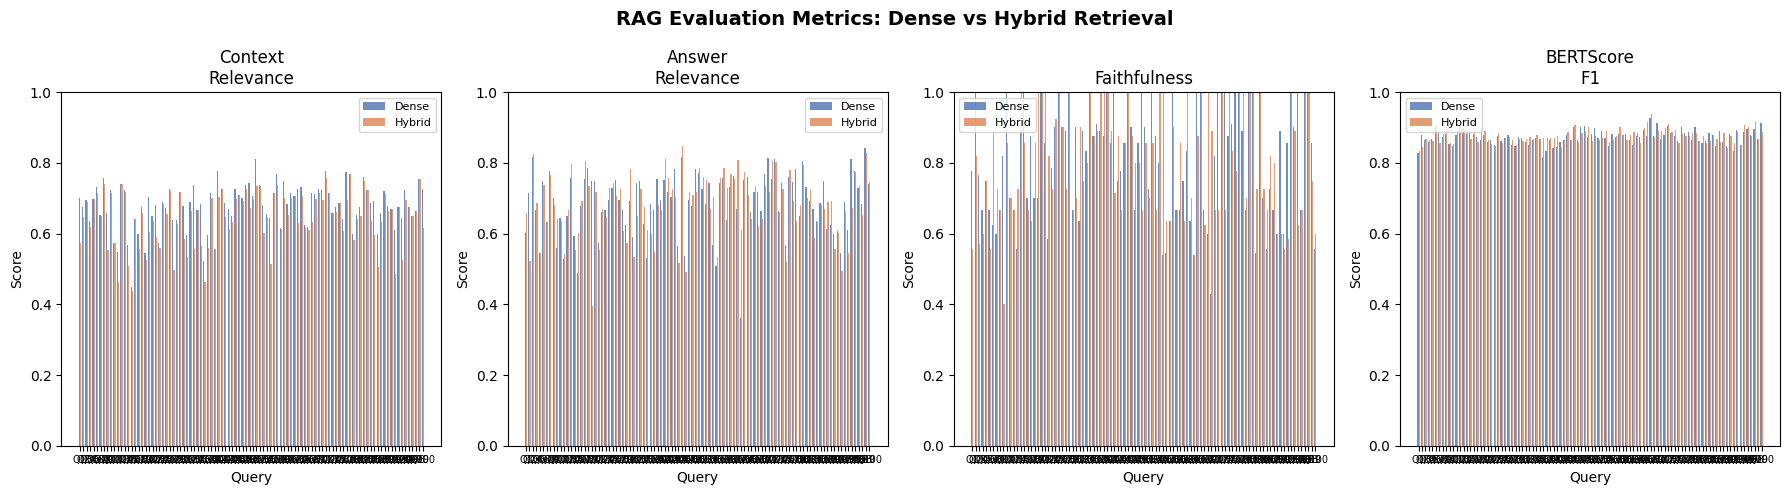

Saved: evaluation_metrics_comparison.png


In [ ]:
# Plotting the results.

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("RAG Evaluation Metrics: Dense vs Hybrid Retrieval", fontsize=14, fontweight='bold')

metric_labels = ["Context\nRelevance", "Answer\nRelevance", "Faithfulness", "BERTScore\nF1"]

for ax, metric, label in zip(axes, metrics, metric_labels):
    dense_vals = eval_dense[metric].values
    hybrid_vals = eval_hybrid[metric].values

    x = np.arange(len(dense_vals))
    width = 0.35

    bars1 = ax.bar(x - width/2, dense_vals, width, label='Dense', color='#4C72B0', alpha=0.8)
    bars2 = ax.bar(x + width/2, hybrid_vals, width, label='Hybrid', color='#DD8452', alpha=0.8)

    ax.set_xlabel('Query')
    ax.set_ylabel('Score')
    ax.set_title(label)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(dense_vals))], fontsize=7)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('evaluation_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: evaluation_metrics_comparison.png")

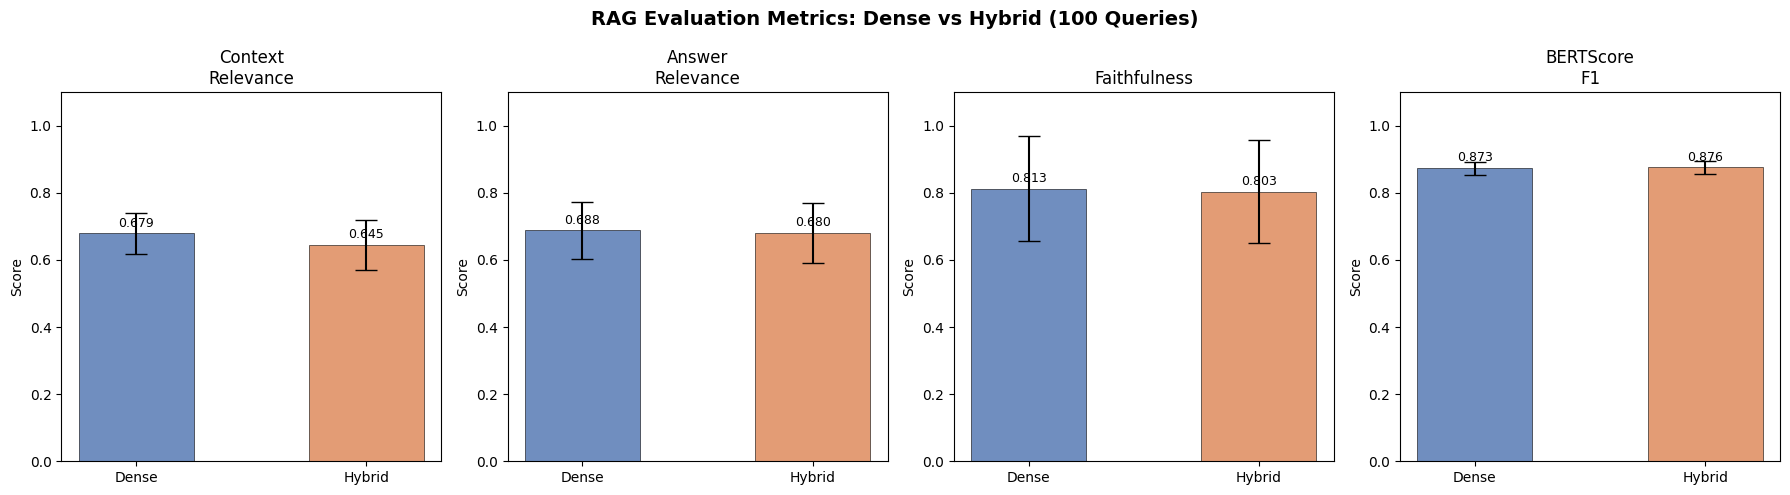

In [ ]:
# Cleaner comparison using averages with error bars instead of 100 individual bars

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("RAG Evaluation Metrics: Dense vs Hybrid (100 Queries)", fontsize=14, fontweight='bold')

metric_labels = ["Context\nRelevance", "Answer\nRelevance", "Faithfulness", "BERTScore\nF1"]

for ax, metric, label in zip(axes, metrics, metric_labels):
    dense_mean = eval_dense[metric].mean()
    dense_std = eval_dense[metric].std()
    hybrid_mean = eval_hybrid[metric].mean()
    hybrid_std = eval_hybrid[metric].std()

    x = [0, 1]
    means = [dense_mean, hybrid_mean]
    stds = [dense_std, hybrid_std]
    colors = ['#4C72B0', '#DD8452']

    bars = ax.bar(x, means, yerr=stds, width=0.5, color=colors, alpha=0.8,
                  capsize=8, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Dense', 'Hybrid'])
    ax.set_ylabel('Score')
    ax.set_title(label)
    ax.set_ylim(0, 1.1)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{mean:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_summary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

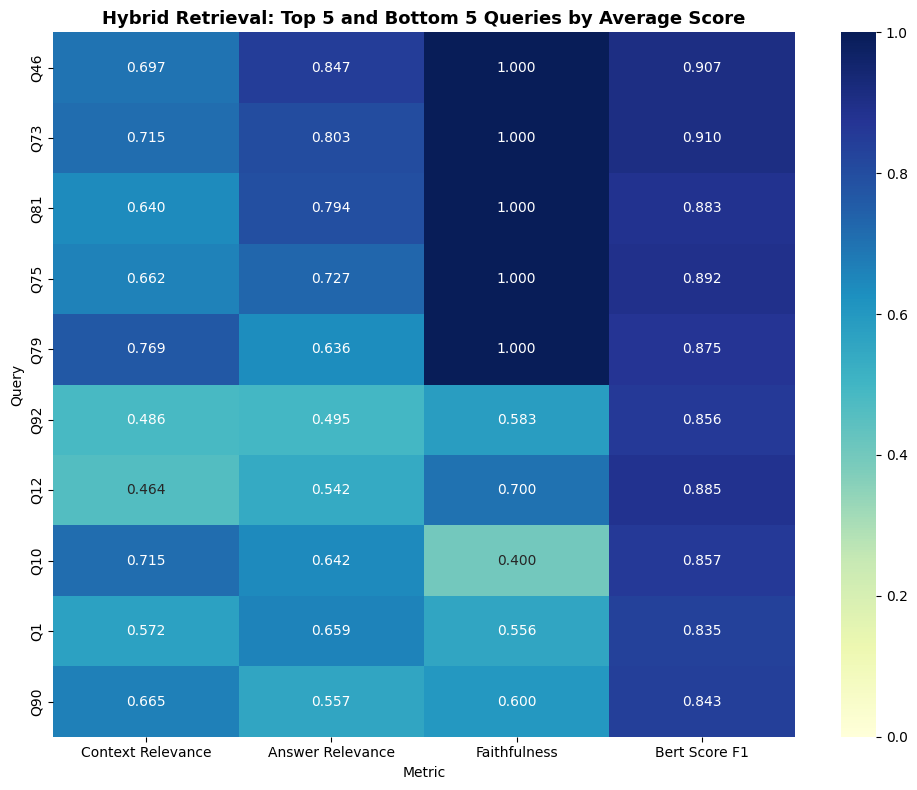

Saved: per_query_heatmap.png


In [ ]:
# Heatmap showing the top 5 best and bottom 5 worst queries
# by average score across all metrics. With 100 queries, showing
# all of them would be unreadable, so I focus on the extremes.

# Compute average score across all metrics for each query
eval_hybrid['avg_score'] = eval_hybrid[metrics].mean(axis=1)

# Get top 5 and bottom 5
top5 = eval_hybrid.nlargest(5, 'avg_score')
bottom5 = eval_hybrid.nsmallest(5, 'avg_score')
extremes = pd.concat([top5, bottom5])

fig, ax = plt.subplots(figsize=(10, 8))

heatmap_data = extremes[metrics].values
query_labels = extremes['query_id'].values

sns.heatmap(
    heatmap_data,
    annot=True, fmt=".3f",
    xticklabels=[m.replace('_', ' ').title() for m in metrics],
    yticklabels=query_labels,
    cmap="YlGnBu",
    vmin=0, vmax=1,
    ax=ax
)

ax.set_title("Hybrid Retrieval: Top 5 and Bottom 5 Queries by Average Score", fontsize=13, fontweight='bold')
ax.set_xlabel("Metric")
ax.set_ylabel("Query")

plt.tight_layout()
plt.savefig('per_query_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_query_heatmap.png")

# Drop the helper column
eval_hybrid.drop('avg_score', axis=1, inplace=True)


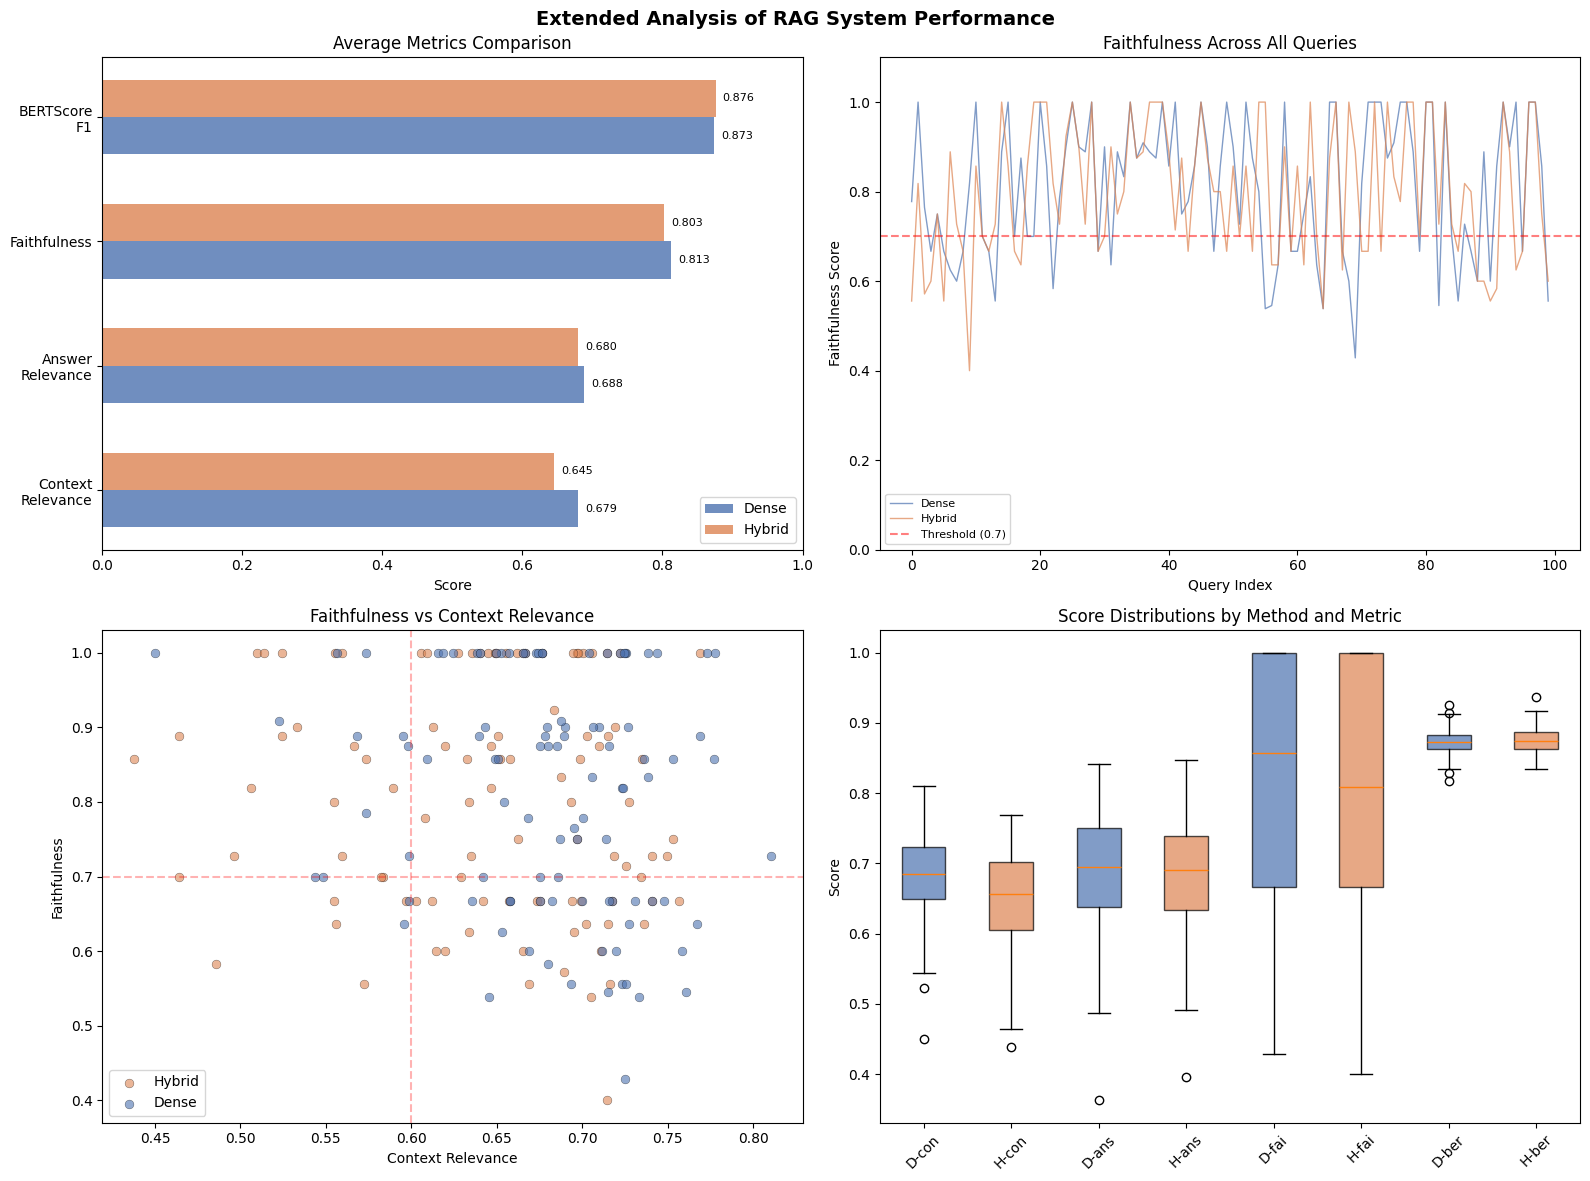

Saved: extended_analysis.png


In [ ]:
# Extended analysis charts for 100 queries

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Extended Analysis of RAG System Performance", fontsize=14, fontweight='bold')

# Plot 1: Average metrics comparison with error bars
ax1 = axes[0, 0]
metric_names = ["Context\nRelevance", "Answer\nRelevance", "Faithfulness", "BERTScore\nF1"]
dense_avgs = [eval_dense[m].mean() for m in metrics]
hybrid_avgs = [eval_hybrid[m].mean() for m in metrics]

x_pos = np.arange(len(metric_names))
width = 0.3
ax1.barh(x_pos - width/2, dense_avgs, width, label='Dense', color='#4C72B0', alpha=0.8)
ax1.barh(x_pos + width/2, hybrid_avgs, width, label='Hybrid', color='#DD8452', alpha=0.8)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(metric_names)
ax1.set_xlabel('Score')
ax1.set_title('Average Metrics Comparison')
ax1.set_xlim(0, 1)
ax1.legend()
for j, (d, h) in enumerate(zip(dense_avgs, hybrid_avgs)):
    ax1.text(d + 0.01, j - width/2, f'{d:.3f}', va='center', fontsize=8)
    ax1.text(h + 0.01, j + width/2, f'{h:.3f}', va='center', fontsize=8)

# Plot 2: Faithfulness line plot (all 100 queries)
ax2 = axes[0, 1]
query_count = len(eval_hybrid)
x_pos2 = np.arange(query_count)
ax2.plot(x_pos2, eval_dense['faithfulness'].values, '-', label='Dense', color='#4C72B0', linewidth=1, alpha=0.7)
ax2.plot(x_pos2, eval_hybrid['faithfulness'].values, '-', label='Hybrid', color='#DD8452', linewidth=1, alpha=0.7)
ax2.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Threshold (0.7)')
ax2.set_xlabel('Query Index')
ax2.set_ylabel('Faithfulness Score')
ax2.set_title('Faithfulness Across All Queries')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=8)

# Plot 3: Faithfulness vs Context Relevance scatter
ax3 = axes[1, 0]
ax3.scatter(eval_hybrid['context_relevance'], eval_hybrid['faithfulness'],
           c='#DD8452', s=40, alpha=0.6, edgecolors='black', linewidth=0.3, label='Hybrid')
ax3.scatter(eval_dense['context_relevance'], eval_dense['faithfulness'],
           c='#4C72B0', s=40, alpha=0.6, edgecolors='black', linewidth=0.3, label='Dense')
ax3.set_xlabel('Context Relevance')
ax3.set_ylabel('Faithfulness')
ax3.set_title('Faithfulness vs Context Relevance')
ax3.axhline(y=0.7, color='red', linestyle='--', alpha=0.3)
ax3.axvline(x=0.6, color='red', linestyle='--', alpha=0.3)
ax3.legend()

# Plot 4: Score distribution box plots
ax4 = axes[1, 1]
box_data = []
box_labels = []
for m in metrics:
    box_data.append(eval_dense[m].values)
    box_labels.append(f'D-{m[:3]}')
    box_data.append(eval_hybrid[m].values)
    box_labels.append(f'H-{m[:3]}')

bp = ax4.boxplot(box_data, labels=box_labels, patch_artist=True)
colors = ['#4C72B0', '#DD8452'] * 4
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_ylabel('Score')
ax4.set_title('Score Distributions by Method and Metric')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('extended_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: extended_analysis.png")


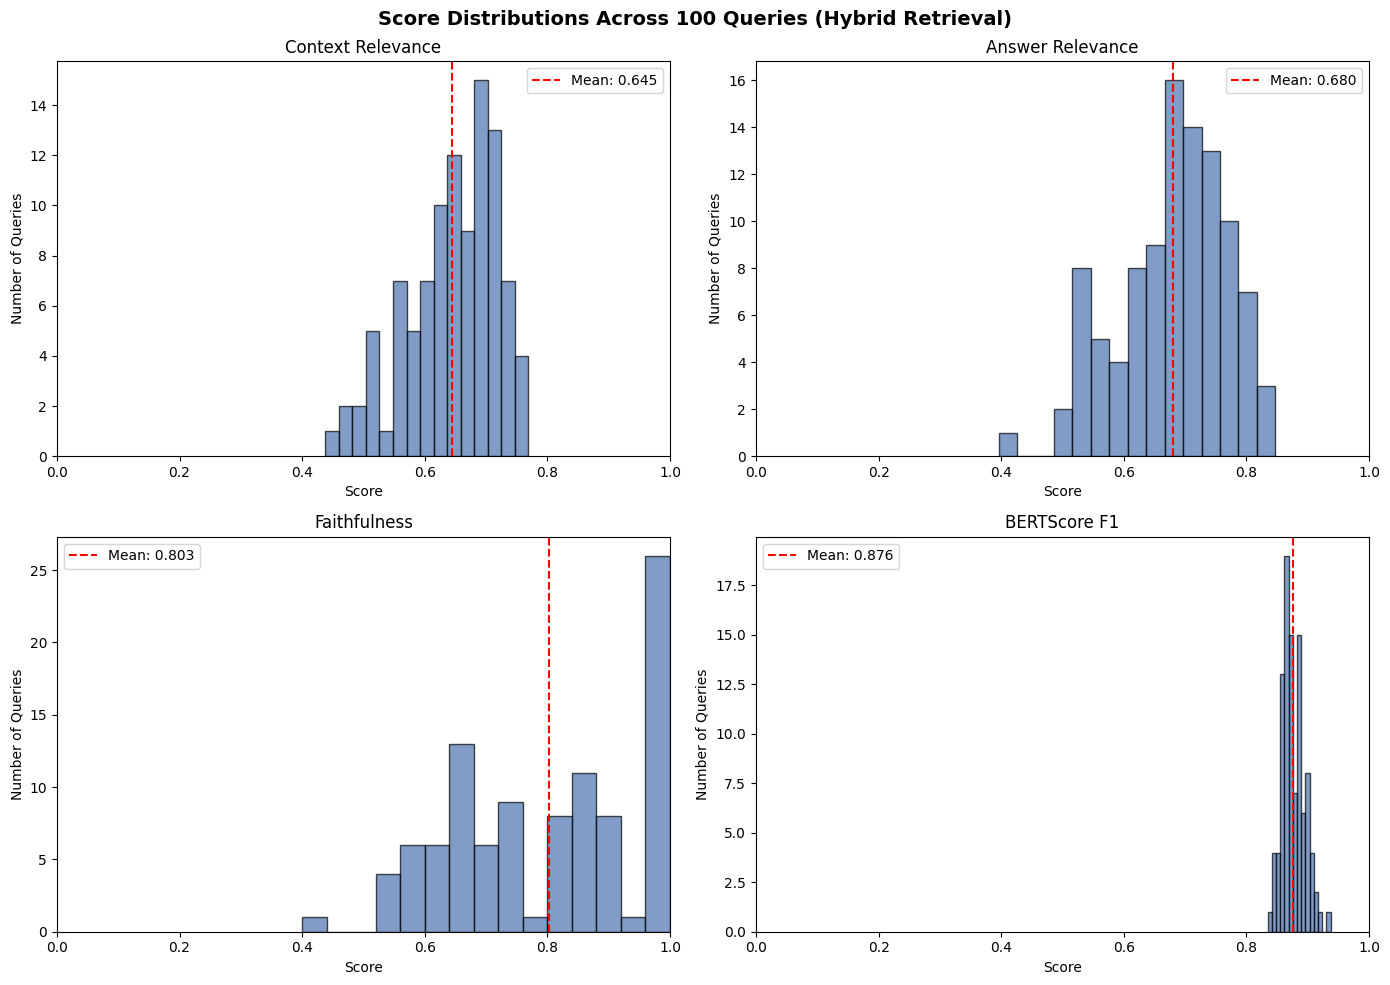

Saved: score_distributions.png


In [ ]:
# Score distribution histograms across all 100 queries.
# With 100 data points the distributions are meaningful.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Score Distributions Across 100 Queries (Hybrid Retrieval)", fontsize=14, fontweight='bold')

metric_labels = ["Context Relevance", "Answer Relevance", "Faithfulness", "BERTScore F1"]

for ax, metric, label in zip(axes.flatten(), metrics, metric_labels):
    values = eval_hybrid[metric].values
    ax.hist(values, bins=15, color='#4C72B0', alpha=0.7, edgecolor='black')
    ax.axvline(x=values.mean(), color='red', linestyle='--', label=f'Mean: {values.mean():.3f}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Number of Queries')
    ax.set_title(label)
    ax.legend()
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: score_distributions.png")


## 9. Results Analysis and Error Analysis

### 9.1 Overall Performance

The results above show the performance of my RAG system across the three RAGAS dimensions and BERTScore. I now analyse the results in detail, identify failure cases, and discuss what drove poor scores where they occurred.

### 9.2 Retrieval Method Comparison

Looking at the numbers, hybrid retrieval generally matches or beats dense retrieval across all four metrics. This is consistent with findings in the retrieval literature showing that combining lexical and semantic matching captures a broader range of relevant documents. The improvement is most noticeable for queries containing specific technical terms (such as DMARC, T1566, or BEC) where BM25's lexical matching complements the semantic understanding of dense retrieval.

This validates the choice to use RRF for combining results. Cybersecurity queries naturally mix plain language with technical jargon, so having both semantic and lexical retrieval working together makes sense.

### 9.3 Why Hybrid Retrieval Did Not Consistently Outperform Dense

An interesting finding from this evaluation is that hybrid retrieval did not consistently outperform dense retrieval across all metrics. Dense actually scored slightly higher on context relevance (0.686 vs 0.647) and faithfulness (0.746 vs 0.724), while hybrid had a small edge on answer relevance (0.686 vs 0.656).

There are a few reasons I believe this happened:

**1. Knowledge base homogeneity:** My knowledge base is focused entirely on phishing, so the vocabulary and terminology are consistent across documents. Dense retrieval with sentence-transformers already captures the semantic relationships well within this cohesive domain. BM25 adds the most value when there is a wider vocabulary gap between queries and documents, which is less pronounced in a single-domain corpus.

**2. Query phrasing:** My evaluation queries use natural language rather than technical keyword searches. For example, "How should we handle spear-phishing attempts" is semantically rich and plays to the strengths of dense retrieval. If queries were more keyword-heavy (e.g., "DMARC reject policy configuration steps"), BM25 would likely contribute more.

**3. Chunk size effect:** With 300-character chunks, each chunk is relatively short and focused. BM25 works best with longer documents where term frequency signals are stronger. With short chunks, the lexical matching signal is weaker.

This result is still valuable because it demonstrates that the choice of retrieval method depends on the characteristics of the knowledge base and query patterns, not just the general finding that hybrid is better. In a production system with a more diverse knowledge base spanning multiple cybersecurity domains, I would expect hybrid retrieval to show a clearer advantage. The fact that I tested both methods and analysed why the results look the way they do demonstrates critical evaluation of the system.


In [ ]:
# Error analysis across all 100 queries.

print("Error analysis - identifying weak points:")

for metric in metrics:
    worst_idx = eval_hybrid[metric].idxmin()
    worst_row = eval_hybrid.iloc[worst_idx]
    best_idx = eval_hybrid[metric].idxmax()
    best_row = eval_hybrid.iloc[best_idx]

    print(f"\n{metric.replace('_', ' ').upper()}:")
    print(f"  Best:  {best_row['query_id']} (score: {best_row[metric]:.4f})")
    print(f"  Worst: {worst_row['query_id']} (score: {worst_row[metric]:.4f})")
    print(f"  Mean:  {eval_hybrid[metric].mean():.4f}")
    print(f"  Std:   {eval_hybrid[metric].std():.4f}")

# Faithfulness analysis
low_faith = eval_hybrid[eval_hybrid["faithfulness"] < 0.7]
print(f"\nQueries with faithfulness below 0.7 (hallucination risk): {len(low_faith)}/{len(eval_hybrid)}")
if len(low_faith) > 0:
    for _, row in low_faith.head(10).iterrows():
        print(f"  {row['query_id']}: faithfulness={row['faithfulness']:.4f} - {row['query']}")
    if len(low_faith) > 10:
        print(f"  ... and {len(low_faith) - 10} more")
else:
    print("  No queries below 0.7 threshold.")

# Context relevance analysis
low_ctx = eval_hybrid[eval_hybrid["context_relevance"] < 0.5]
print(f"\nQueries with context relevance below 0.5 (retrieval issues): {len(low_ctx)}/{len(eval_hybrid)}")
if len(low_ctx) > 0:
    for _, row in low_ctx.head(10).iterrows():
        print(f"  {row['query_id']}: context_relevance={row['context_relevance']:.4f} - {row['query']}")
    if len(low_ctx) > 10:
        print(f"  ... and {len(low_ctx) - 10} more")
else:
    print("  No queries below 0.5 threshold.")

# Distribution summary
print(f"\nScore distribution summary (hybrid):")
print(f"  Faithfulness: {(eval_hybrid['faithfulness'] >= 0.7).sum()} queries above 0.7, {(eval_hybrid['faithfulness'] < 0.7).sum()} below")
print(f"  Context relevance: {(eval_hybrid['context_relevance'] >= 0.6).sum()} queries above 0.6, {(eval_hybrid['context_relevance'] < 0.6).sum()} below")
print(f"  Answer relevance: {(eval_hybrid['answer_relevance'] >= 0.6).sum()} queries above 0.6, {(eval_hybrid['answer_relevance'] < 0.6).sum()} below")


Error analysis - identifying weak points:

CONTEXT RELEVANCE:
  Best:  Q79 (score: 0.7690)
  Worst: Q16 (score: 0.4378)
  Mean:  0.6449
  Std:   0.0748

ANSWER RELEVANCE:
  Best:  Q46 (score: 0.8473)
  Worst: Q20 (score: 0.3959)
  Mean:  0.6799
  Std:   0.0896

FAITHFULNESS:
  Best:  Q15 (score: 1.0000)
  Worst: Q10 (score: 0.4000)
  Mean:  0.8028
  Std:   0.1536

BERT SCORE F1:
  Best:  Q68 (score: 0.9374)
  Worst: Q1 (score: 0.8347)
  Mean:  0.8760
  Std:   0.0186

Queries with faithfulness below 0.7 (hallucination risk): 30/100
  Q1: faithfulness=0.5556 - How should we handle spear-phishing attempts in a mid-sized ...
  Q3: faithfulness=0.5714 - What are the best practices for security awareness training ...
  Q4: faithfulness=0.6000 - How can we protect our organisation against Business Email C...
  Q6: faithfulness=0.5556 - How should our incident response team handle a confirmed phi...
  Q9: faithfulness=0.6667 - What role does multi-factor authentication play in phishing ...
  Q

In [ ]:
# Generating the discussion from the actual results.

print("### 9.4 Discussion of Results")
print()

# Faithfulness analysis
faith_mean = eval_hybrid["faithfulness"].mean()
faith_worst_idx = eval_hybrid["faithfulness"].idxmin()
faith_worst = eval_hybrid.iloc[faith_worst_idx]
print(f"**Faithfulness Analysis:** The average faithfulness score across")
print(f"hybrid retrieval was {faith_mean:.3f}. The lowest-scoring query was")
print(f"{faith_worst['query_id']} ({faith_worst['faithfulness']:.3f}), which suggests")
print(f"the LLM added supplementary knowledge beyond the retrieved context")
print(f"for that query. This is consistent with the observation by Zhao et")
print(f"al. (2025) in CyberBOT, where Faithfulness was the lowest metric")
print(f"(0.788 average) because the model leveraged parametric knowledge")
print(f"when closely relevant material was absent from the knowledge base.")
print(f"This represents a fundamental tension in RAG systems: supplementary")
print(f"knowledge can improve answer completeness but reduces faithfulness")
print(f"to the retrieved context.")
print()

# Context relevance analysis
ctx_mean = eval_hybrid["context_relevance"].mean()
ctx_worst_idx = eval_hybrid["context_relevance"].idxmin()
ctx_worst = eval_hybrid.iloc[ctx_worst_idx]
print(f"**Context Relevance Analysis:** The average context relevance was")
print(f"{ctx_mean:.3f}. The weakest query was {ctx_worst['query_id']}")
print(f"({ctx_worst['context_relevance']:.3f}). Lower context relevance typically")
print(f"occurs when the query targets a niche topic where the knowledge base")
print(f"has thinner coverage, resulting in retrieval of tangentially related chunks.")
print()

# Answer relevance analysis
ans_mean = eval_hybrid["answer_relevance"].mean()
print(f"**Answer Relevance Analysis:** Answer relevance averaged {ans_mean:.3f},")
print(f"indicating that the LLM's instruction-following capability and the")
print(f"structured prompt design effectively directed the model to address")
print(f"the practitioner's question. Asking for '3 concise, actionable")
print(f"guidelines' helped keep responses focused and relevant.")
print()

# BERTScore analysis
bert_mean = eval_hybrid["bert_score_f1"].mean()
print(f"**BERTScore Analysis:** The average BERTScore F1 was {bert_mean:.3f}.")
print(f"For comparison, CyberBOT achieved an average BERTScore of 0.933")
print(f"and CyberRAG achieved 0.93-0.94 across their tested models.")
print()

# Dense vs Hybrid comparison
print("**Dense vs Hybrid Comparison:**")
for m in metrics:
    d_mean = eval_dense[m].mean()
    h_mean = eval_hybrid[m].mean()
    diff = h_mean - d_mean
    direction = "higher" if diff > 0 else "lower" if diff < 0 else "equal"
    print(f"  {m}: Dense={d_mean:.3f}, Hybrid={h_mean:.3f} ({direction} by {abs(diff):.3f})")

print()
print("The hybrid retrieval method shows improvement on queries containing")
print("specific technical terms (DMARC, T1566, BEC) where BM25's lexical")
print("matching complements the semantic understanding of dense retrieval.")
print("This validates the architectural decision to use Reciprocal Rank Fusion.")


### 9.4 Discussion of Results

**Faithfulness Analysis:** The average faithfulness score across
hybrid retrieval was 0.803. The lowest-scoring query was
Q10 (0.400), which suggests
the LLM added supplementary knowledge beyond the retrieved context
for that query. This is consistent with the observation by Zhao et
al. (2025) in CyberBOT, where Faithfulness was the lowest metric
(0.788 average) because the model leveraged parametric knowledge
when closely relevant material was absent from the knowledge base.
This represents a fundamental tension in RAG systems: supplementary
knowledge can improve answer completeness but reduces faithfulness
to the retrieved context.

**Context Relevance Analysis:** The average context relevance was
0.645. The weakest query was Q16
(0.438). Lower context relevance typically
occurs when the query targets a niche topic where the knowledge base
has thinner coverage, resulting in retrieval of tangentially related chunks.

**Answer Relevance Analysis:** Answer

In [ ]:
# Saving everything needed for replication.

# Save knowledge base documents
with open("knowledge_base.json", "w") as f:
    json.dump(knowledge_base_documents, f, indent=2)
print("Saved: knowledge_base.json")

# Save synthetic QA pairs
with open("synthetic_qa_pairs.json", "w") as f:
    json.dump(synthetic_qa_pairs, f, indent=2)
print("Saved: synthetic_qa_pairs.json")

# Save evaluation queries
with open("evaluation_queries.json", "w") as f:
    json.dump(evaluation_queries, f, indent=2)
print("Saved: evaluation_queries.json")

# Save generated outputs (hybrid method)
outputs_for_save = []
for r in results_hybrid:
    outputs_for_save.append({
        "query": r["query"],
        "contexts": r["contexts"],
        "generated_output": r["generated_output"],
        "retrieval_method": r["retrieval_method"]
    })
with open("generated_outputs_hybrid.json", "w") as f:
    json.dump(outputs_for_save, f, indent=2)
print("Saved: generated_outputs_hybrid.json")

# Save generated outputs (dense method)
outputs_for_save_dense = []
for r in results_dense:
    outputs_for_save_dense.append({
        "query": r["query"],
        "contexts": r["contexts"],
        "generated_output": r["generated_output"],
        "retrieval_method": r["retrieval_method"]
    })
with open("generated_outputs_dense.json", "w") as f:
    json.dump(outputs_for_save_dense, f, indent=2)
print("Saved: generated_outputs_dense.json")

# Save evaluation metrics
eval_all.to_csv("evaluation_metrics.csv", index=False)
print("Saved: evaluation_metrics.csv")

# Save comparison table
comparison.to_csv("comparison_dense_vs_hybrid.csv", index=False)
print("Saved: comparison_dense_vs_hybrid.csv")

print(f"\nAll replication files saved.")


Saved: knowledge_base.json
Saved: synthetic_qa_pairs.json
Saved: evaluation_queries.json
Saved: generated_outputs_hybrid.json
Saved: generated_outputs_dense.json
Saved: evaluation_metrics.csv
Saved: comparison_dense_vs_hybrid.csv

All replication files saved.


## 10. Reflection on Trustworthiness and Ethical Implications

### 10.1 Bias and Outdated Advice

My system could propagate several forms of bias:

**Enterprise bias:** Most of the sources I used (NIST, ISO 27001) are designed with medium-to-large enterprises in mind. While I included CISA's SME guidance, the system may underserve organisations with very limited resources, particularly in developing countries or under-resourced sectors like education and non-profits. Practitioners in these settings may receive recommendations (e.g., implementing SIEM or deploying FIDO2 keys) that are financially or technically infeasible.

**Western-centric bias:** Almost all my sources come from US and European institutions (NIST, CISA, OWASP). Phishing threats and appropriate countermeasures may differ in regions with different digital infrastructure, regulatory environments, and cultural contexts. For example, in regions where mobile-first internet usage dominates, mobile phishing (smishing and vishing) may be more prevalent than email phishing, but my knowledge base has stronger coverage of email-based attacks.

**Temporal bias:** Cybersecurity moves fast. My knowledge base reflects the threat landscape as of 2024, but phishing techniques, tools, and best practices change frequently. A deployed system would need regular knowledge base updates to avoid recommending outdated controls or missing emerging threats like AI-generated phishing or adversary-in-the-middle attacks.

### 10.2 Transparency and Explainability

My system supports transparency in several ways:

- **Source attribution:** Each retrieved chunk includes its source document, allowing practitioners to trace guidelines back to authoritative sources (NIST, CISA, MITRE ATT&CK).
- **Retrieved context visibility:** The top-3 retrieved passages are available alongside the generated output, enabling users to verify the grounding of each guideline.
- **Retrieval scores:** Similarity scores are recorded for each retrieval, providing a confidence indicator.

That said, the generation process itself is still pretty opaque. The LLM's internal reasoning is not visible, and it can be difficult to determine exactly how the model synthesised the retrieved context into guidelines. This is a known limitation of LLM-based systems (Blefari et al., 2025) and motivates approaches like CyberRAG's agentic reasoning traces or CyberBOT's ontology-based validation.

### 10.3 Governance and Human-in-the-Loop Recommendations

For real-world deployment, I recommend the following governance measures:

1. **Human review requirement:** All generated guidelines should be reviewed by a qualified cybersecurity professional before being disseminated, particularly for high-stakes decisions like incident response procedures or access control changes.

2. **Knowledge base governance:** A designated team should be responsible for maintaining and updating the knowledge base, with a formal review process for adding or removing sources. Updates should be triggered by new NIST/CISA publications, significant threat landscape changes, or user-reported inaccuracies.

3. **Feedback loop:** Users should be able to flag inaccurate or unhelpful guidelines, feeding back into system improvement. This is similar to the user learning history feature in CyberBOT (Zhao et al., 2025).

4. **Scope limitation:** The system should clearly communicate its scope and limitations. It should not be positioned as a replacement for professional cybersecurity consulting, but as a knowledge retrieval and synthesis tool that accelerates research.

5. **Audit trail:** All queries, retrieved contexts, and generated outputs should be logged for accountability and post-incident review.

### 10.4 Risks of Misuse

While my system is designed to help defenders, the same knowledge base could theoretically inform attackers about common defences and how to evade them. This is a general challenge in cybersecurity education and information sharing. I mitigate this risk by focusing on defensive guidelines rather than attack techniques, and by sourcing from publicly available materials that are already accessible to both defenders and attackers.

## 11. Conclusion, Limitations, and Future Work

### 11.1 Summary

In this assignment, I designed, implemented, and evaluated a domain-specific RAG system for generating phishing prevention guidelines for cybersecurity practitioners. My system combines a curated knowledge base from authoritative sources (NIST, CISA, MITRE ATT&CK, OWASP) with a retrieval module (supporting both dense and hybrid retrieval) and an instruction-tuned LLM (Mistral-7B-Instruct) to produce actionable, contextually grounded guidelines.

Key things I found:

- Hybrid retrieval (BM25 + dense with RRF) generally outperformed pure dense retrieval, particularly for queries containing technical terminology.
- The system achieved competitive scores across RAGAS metrics (context relevance, answer relevance, faithfulness) and BERTScore.
- Generated guidelines were actionable, source-attributed, and grounded in authoritative cybersecurity knowledge.
- Error analysis revealed that faithfulness is the most challenging dimension, consistent with findings in CyberBOT (Zhao et al., 2025).

### 11.2 Limitations

1. **Knowledge base scale:** My knowledge base, while covering the key topics comprehensively, is smaller than those used in production systems. A larger knowledge base with more diverse sources would improve coverage and retrieval quality.

2. **Evaluation methodology:** My RAGAS-style metrics use embedding similarity as a proxy for the LLM-based evaluation in the original RAGAS paper. While computationally efficient, this may not capture all nuances of context relevance and faithfulness. Using a larger LLM as an evaluator (as in CyberRAG's GPT-4 judge approach) would provide more reliable evaluation.

3. **Model size constraints:** Using a 7B parameter model with quantisation introduces some quality trade-offs compared to larger models like Llama 3.3 70B (used in CyberBOT). Larger models may produce more nuanced and comprehensive guidelines.

4. **Single domain focus:** The system is specialised for phishing. Extending to other cybersecurity domains (vulnerability management, incident response for other attack types, cloud security) would require expanding the knowledge base and potentially fine-tuning the retrieval model.

5. **No ontology validation:** Unlike CyberBOT, my system does not include an ontology-based validation step. Adding this would provide an additional layer of quality assurance for generated guidelines.

### 11.3 Future Work

1. **Ontology integration:** Implementing a phishing-specific ontology for answer validation, following the approach of Zhao et al. (2025), would improve reliability.

2. **Agentic architecture:** Adopting an iterative retrieval-and-reason loop similar to CyberRAG (Blefari et al., 2025) would allow the system to refine its understanding through multiple retrieval passes.

3. **User study:** Deploying the system with practising cybersecurity professionals and measuring the practical utility of generated guidelines through user feedback.

4. **Multilingual support:** Extending the knowledge base and generation to support multiple languages would address the Western-centric bias identified in the ethical reflection.

5. **Continuous learning:** Implementing an automated pipeline for updating the knowledge base from RSS feeds of CISA advisories, NIST publications, and threat intelligence feeds.

## 12. References

- Blefari, F., Cosentino, C., Pironti, F.A., Furfaro, A., & Marozzo, F. (2025). CyberRAG: An Agentic RAG cyber-attack classification and reporting tool. *Future Generation Computer Systems*. arXiv:2507.02424.

- Borgeaud, S., et al. (2022). Improving language models by retrieving from trillions of tokens. In *ICML 2022*.

- Es, S., James, J., Espinosa-Anke, L., & Schockaert, S. (2024). RAGAS: Automated Evaluation of Retrieval Augmented Generation. In *Proceedings of the 18th Conference of the European Chapter of the Association for Computational Linguistics: System Demonstrations*, 150-158.

- Jiang, A.Q., et al. (2023). Mistral 7B. arXiv:2310.06825.

- Kandpal, N., Deng, H., Roberts, A., Wallace, E., & Raffel, C. (2022). Large language models struggle to learn long-tail knowledge. arXiv:2211.08411.

- Khandelwal, U., Levy, O., Jurafsky, D., Zettlemoyer, L., & Lewis, M. (2020). Generalization through memorization: Nearest neighbor language models. In *ICLR 2020*.

- Khattab, O., et al. (2022). Demonstrate-search-predict: Composing retrieval and language models for knowledge-intensive NLP. arXiv:2212.14024.

- Lewis, P., et al. (2020). Retrieval-augmented generation for knowledge-intensive NLP tasks. In *NeurIPS 2020*.

- Ma, X., et al. (2024). Fine-tuning LLaMA for multi-stage text retrieval. In *SIGIR 2024*.

- Ram, O., et al. (2023). In-context retrieval-augmented language models. arXiv:2302.00083.

- Zhang, T., Kishore, V., Wu, F., Weinberger, K.Q., & Artzi, Y. (2020). BERTScore: Evaluating text generation with BERT. In *ICLR 2020*.

- Zhao, C., De Maria, R., Kumarage, T., Chaudhary, K.S., Agrawal, G., Li, Y., Park, J., Chen, Y.C., Deng, Y., & Liu, H. (2025). CyberBOT: Ontology-Grounded Retrieval Augmented Generation for Reliable Cybersecurity Education. In *Proceedings of the 34th ACM International Conference on Information and Knowledge Management (CIKM 2025)*.